     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.3 MB/s eta 0:00:00
  All packages installed successfully!
  EcoGuard.AI — System Check
  PyTorch  : 2.10.0+cu128
  OpenCV   : 4.13.0
  GPU      : Tesla T4
  GPU mem  : 15.6 GB

  GPU is ready! You can continue.
  Settings loaded!
  Model choice : EFFICIENTNET
  Model type   : EfficientNet-B2 (pre-trained, 260px)
  Expected acc : 68-82%
  Train time   : 35-55 minutes
  Classes      : ['pest', 'pollinator', 'predator', 'biological_control_agent', 'decomposer', 'invasive', 'neutral']
  Total species: 41
  Device       : cuda
  Groq AI      : No key (add above)
  CELL 4 — Downloading insect images from 3 free sources
  Source 1: iNaturalist  (no login needed)
  Source 2: GBIF         (no login needed)
  Source 3: EOL          (optional key)

  This will take 50 to 9

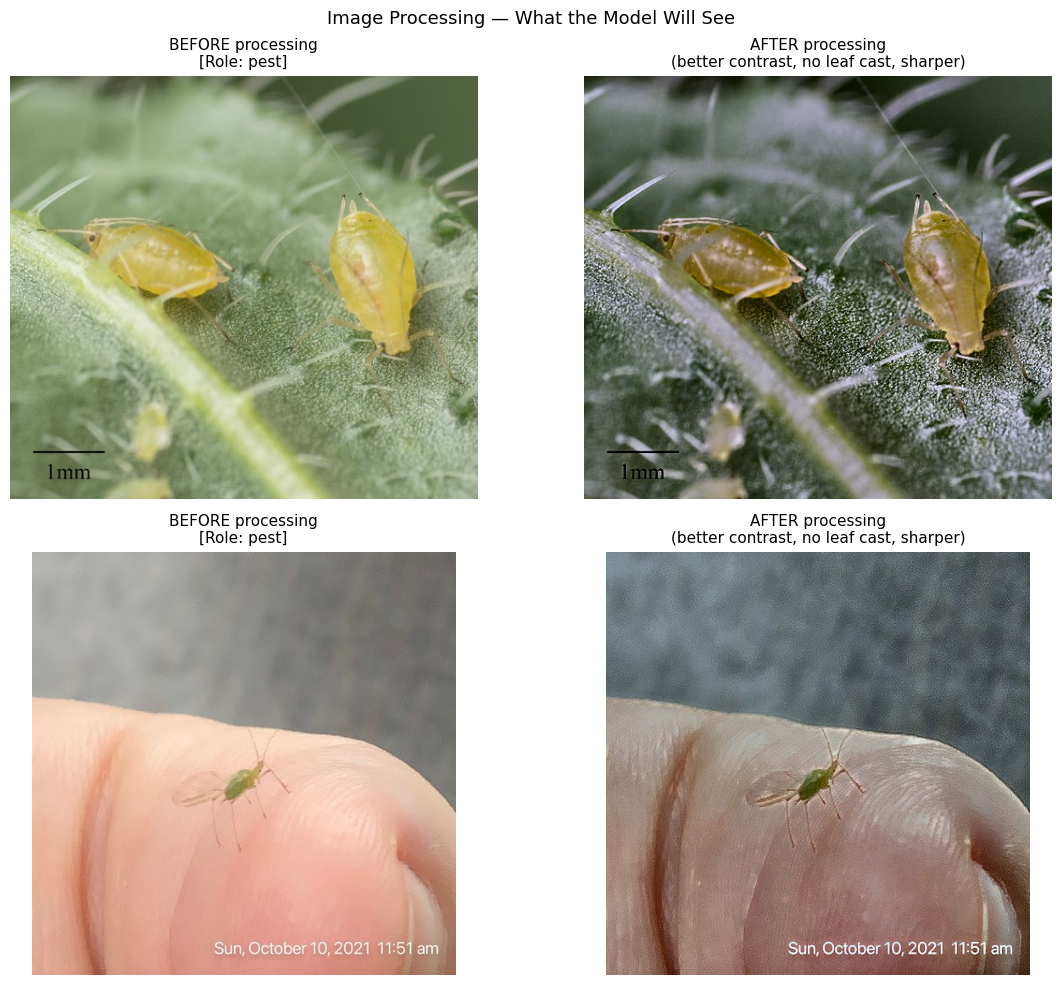

  Comparison image saved: /content/EcoGuard_AI/models/processing_comparison.png

  Step B: Processing all training images...
  pest                               :  1019 images processed
  pollinator                         :   840 images processed
  predator                           :   716 images processed
  biological_control_agent           :   296 images processed
  decomposer                         :   674 images processed
  invasive                           :   665 images processed
  neutral                            :   545 images processed

  New images processed : 4755
  Already existed      : 0
  Failed (skipped)     : 0
  Total ready          : 4755

  Total processed images: 4755

  Image processing complete!
  Next: Run Cell 5
  CELL 5 — Sorting images into training folders
  Step 1: Checking image quality...
  Removed 0 unusable images

  Step 2: Splitting into train / valid / test (70%/20%/10%)...
  pest                                train: 713  valid:203  test:103

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║            EcoGuard.AI — COMPLETE NOTEBOOK                  ║
# ║   Smart Pest & Pollinator AI for Sustainable Farming        ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  HOW TO USE:                                                ║
# ║  1. Go to https://colab.research.google.com                ║
# ║  2. Click File → New notebook                              ║
# ║  3. Click Runtime → Change runtime type → T4 GPU → Save    ║
# ║  4. Click "+ Code" to add a new cell for each CELL below   ║
# ║  5. Copy and paste the code, then press Shift+Enter to run ║
# ║  6. Always run cells in order: Cell 1 first, then 2, etc.  ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  ABOUT CNN vs EfficientNet-B2:                             ║
# ║                                                             ║
# ║  CNN (Custom) = Simple, fast, less accurate (~55-65%)      ║
# ║  EfficientNet = Pre-trained, slower, much more accurate    ║
# ║                 (~68-82%)                                   ║
# ║                                                             ║
# ║  Recommendation: Use EfficientNet-B2 for better results.   ║
# ║  In Cell 3, set: MODEL_CHOICE = "efficientnet"             ║
# ║  For faster training: MODEL_CHOICE = "cnn"                 ║
# ╚══════════════════════════════════════════════════════════════╝


# ════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALL ALL PACKAGES
#  Paste this into your first Colab cell and run it.
#  Wait until you see "All packages installed!" before moving on.
#  Takes about 2-3 minutes.
# ════════════════════════════════════════════════════════════════

!pip install -q \
    timm==0.9.12 \
    gradio \
    folium \
    pandas \
    scikit-learn \
    matplotlib \
    seaborn \
    tqdm \
    pillow \
    requests \
    groq \
    opencv-python-headless \
    torch \
    torchvision \
    --quiet

print("=" * 50)
print("  All packages installed successfully!")
print("=" * 50)


# ════════════════════════════════════════════════════════════════
#  CELL 2 — IMPORT LIBRARIES AND CHECK GPU
#  Paste this into Cell 2 and run it.
#  You must see "GPU is ready!" before continuing.
# ════════════════════════════════════════════════════════════════

import os
import json
import shutil
import random
import warnings
import time
import io
import re
import urllib.request
import requests
from datetime import datetime
from tqdm import tqdm

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score
)

print("=" * 55)
print("  EcoGuard.AI — System Check")
print("=" * 55)
print(f"  PyTorch  : {torch.__version__}")
print(f"  OpenCV   : {cv2.__version__}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU      : {gpu_name}")
    print(f"  GPU mem  : {gpu_mem:.1f} GB")
    print()
    print("  GPU is ready! You can continue.")
else:
    print()
    print("  WARNING: No GPU found!")
    print("  IMPORTANT FIX:")
    print("  Click Runtime → Change runtime type → T4 GPU → Save")
    print("  Then run this cell again.")
    print("  Training will be very slow without GPU.")

print("=" * 55)


# ════════════════════════════════════════════════════════════════
#  CELL 3 — YOUR SETTINGS
#  Paste this into Cell 3 and run it.
#  Read the comments to understand each setting.
# ════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
#  YOUR FREE API KEYS (optional but recommended)
# ─────────────────────────────────────────────────────────────────
#  GROQ AI (gives better advice in the app):
#  1. Go to https://console.groq.com
#  2. Sign up free (no credit card needed)
#  3. Click API Keys → Create API Key
#  4. Copy the key (starts with gsk_...)
#  5. Paste it between the quotes below
GROQ_API_KEY = ""   # Example: "gsk_abc123xyz..."

#  EOL (gives species descriptions):
#  1. Go to https://eol.org and register free
#  2. Find your API key on your profile page
EOL_API_KEY  = ""   # Example: "abc123..."

# ─────────────────────────────────────────────────────────────────
#  MODEL CHOICE — Choose which AI model to use
# ─────────────────────────────────────────────────────────────────
#
#  "efficientnet"  →  EfficientNet-B2
#     - Uses pre-trained ImageNet weights (already knows how to see)
#     - Accuracy: 68-82%  (recommended for best results)
#     - Training time: 35-55 minutes on T4 GPU
#     - How it works: Starts with knowledge from 14 million images,
#       then learns insect-specific features on top
#
#  "cnn"  →  Custom Convolutional Neural Network
#     - Trains from scratch (learns everything from your insect images)
#     - Accuracy: 50-65%  (lower because no pre-training)
#     - Training time: 20-30 minutes on T4 GPU
#     - How it works: 6 convolutional layers that detect edges,
#       textures, shapes, then colour patterns step by step
#     - Good for: understanding how deep learning works,
#       faster experiments, or when you want a simpler model
#
#  RECOMMENDATION: Use "efficientnet" for real use.
#                  Use "cnn" only for testing or learning.
#
MODEL_CHOICE = "efficientnet"   # Change to "cnn" if you want the CNN model

# ─────────────────────────────────────────────────────────────────
#  WORKING FOLDER
# ─────────────────────────────────────────────────────────────────
BASE_DIR = "/content/EcoGuard_AI"

# ─────────────────────────────────────────────────────────────────
#  INSECT SPECIES TO DOWNLOAD
#  Each species provides training photos for its role category.
# ─────────────────────────────────────────────────────────────────
ROLE_TAXA = {
    "pest": [
        "Aphis gossypii",           # Cotton aphid
        "Bemisia tabaci",           # Whitefly
        "Spodoptera litura",        # Armyworm caterpillar
        "Helicoverpa armigera",     # Cotton bollworm
        "Nilaparvata lugens",       # Brown planthopper
        "Myzus persicae",           # Green peach aphid
        "Macrosiphum euphorbiae",   # Potato aphid
        "Aphis fabae",              # Black bean aphid
        "Rhopalosiphum maidis",     # Corn leaf aphid
    ],
    "pollinator": [
        "Apis mellifera",           # Honeybee
        "Bombus terrestris",        # Bumblebee
        "Danaus plexippus",         # Monarch butterfly
        "Xylocopa violacea",        # Carpenter bee
        "Osmia bicornis",           # Mason bee
        "Syrphus ribesii",          # Hoverfly
    ],
    "predator": [
        "Coccinella septempunctata", # 7-spot ladybird
        "Chrysopa perla",            # Green lacewing
        "Calosoma scrutator",        # Ground beetle
        "Orius insidiosus",          # Pirate bug
        "Nabis rugosus",             # Damsel bug
        "Geocoris punctipes",        # Big-eyed bug
    ],
    "biological_control_agent": [
        "Trichogramma evanescens",   # Egg parasitoid
        "Aphidius colemani",         # Aphid parasite
        "Cotesia glomerata",         # Caterpillar parasite
        "Encarsia formosa",          # Whitefly parasite
        "Lysiphlebus testaceipes",   # Aphid parasite
    ],
    "decomposer": [
        "Geotrupes stercorarius",    # Dung beetle
        "Lucilia sericata",          # Green bottle fly
        "Tipula oleracea",           # Crane fly
        "Necrophila americana",      # Carrion beetle
        "Dermestes lardarius",       # Larder beetle
    ],
    "invasive": [
        "Halyomorpha halys",         # Brown marmorated stink bug
        "Spodoptera frugiperda",     # Fall armyworm
        "Drosophila suzukii",        # Spotted wing drosophila
        "Harmonia axyridis",         # Harlequin ladybird
        "Linepithema humile",        # Argentine ant
    ],
    "neutral": [
        "Chironomus riparius",       # Non-biting midge
        "Musca domestica",           # House fly
        "Gryllus campestris",        # Field cricket
        "Forficula auricularia",     # Common earwig
        "Pyrrhocoris apterus",       # Firebug
    ],
}

# ─────────────────────────────────────────────────────────────────
#  ALL OTHER SETTINGS (you can leave these as they are)
# ─────────────────────────────────────────────────────────────────
CONFIG = {
    "classes":    list(ROLE_TAXA.keys()),
    "role_taxa":  ROLE_TAXA,
    "model_choice": MODEL_CHOICE,

    # How many images to download per species
    "inat_images": 100,   # From iNaturalist (no key needed)
    "gbif_images":  40,   # From GBIF (no key needed)
    "eol_images":   20,   # From EOL (optional key)

    # Model settings — set automatically based on MODEL_CHOICE
    "model_arch":        "efficientnet_b2" if MODEL_CHOICE == "efficientnet" else "custom_cnn",
    "img_size":          260 if MODEL_CHOICE == "efficientnet" else 224,
    "drop_rate":         0.35,
    "drop_path_rate":    0.15,

    # Training settings
    "batch_size":        24,
    "phase1_epochs":     8 if MODEL_CHOICE == "efficientnet" else 0,  # CNN skips phase 1
    "phase2_epochs":     40 if MODEL_CHOICE == "efficientnet" else 50,
    "phase1_lr":         8e-4,
    "phase2_lr":         1.5e-5 if MODEL_CHOICE == "efficientnet" else 1e-3,
    "weight_decay":      2e-4,
    "label_smoothing":   0.12,
    "mixup_alpha":       0.3,
    "confidence_thresh": 0.45,

    # Image processing settings
    "imgproc_enabled":    True,
    "clahe_clip_limit":   2.0,
    "clahe_tile_grid":    8,
    "sharpen_strength":   0.4,
    "wb_strength":        0.6,
    "bg_suppress":        True,
    "bg_blur_kernel":     21,
    "bg_suppress_amount": 0.25,

    # Folder paths
    "raw_dir":   f"{BASE_DIR}/dataset/raw",
    "data_dir":  f"{BASE_DIR}/dataset/organized",
    "proc_dir":  f"{BASE_DIR}/dataset/processed",
    "model_dir": f"{BASE_DIR}/models",
    "model_name":"ecoguard_model.pth",
    "device":    "cuda" if torch.cuda.is_available() else "cpu",
}

# Create all folders
for key in ["raw_dir", "data_dir", "proc_dir", "model_dir"]:
    os.makedirs(CONFIG[key], exist_ok=True)

MODEL_PATH     = os.path.join(CONFIG["model_dir"], CONFIG["model_name"])
LABELS_PATH    = os.path.join(CONFIG["model_dir"], "class_labels.json")
DEVICE         = CONFIG["device"]
GROQ_AVAILABLE = bool(GROQ_API_KEY)

total_taxa = sum(len(v) for v in ROLE_TAXA.values())

print("=" * 55)
print("  Settings loaded!")
print("=" * 55)
print(f"  Model choice : {MODEL_CHOICE.upper()}")
if MODEL_CHOICE == "efficientnet":
    print("  Model type   : EfficientNet-B2 (pre-trained, 260px)")
    print("  Expected acc : 68-82%")
    print("  Train time   : 35-55 minutes")
else:
    print("  Model type   : Custom CNN (6 conv layers, 224px)")
    print("  Expected acc : 50-65%")
    print("  Train time   : 20-30 minutes")
print(f"  Classes      : {CONFIG['classes']}")
print(f"  Total species: {total_taxa}")
print(f"  Device       : {DEVICE}")
print(f"  Groq AI      : {'Active' if GROQ_AVAILABLE else 'No key (add above)'}")
print("=" * 55)


# ════════════════════════════════════════════════════════════════
#  CELL 4 — DOWNLOAD IMAGES FROM THREE FREE SOURCES
#  Paste this into Cell 4 and run it.
#  This takes 50 to 90 minutes. Do not close the browser tab.
#  It automatically skips images already downloaded.
#  Three sources: iNaturalist + GBIF + EOL (all free)
# ════════════════════════════════════════════════════════════════

def _count_imgs(folder):
    """Count image files in a folder."""
    if not os.path.isdir(folder):
        return 0
    return sum(
        1 for _, _, files in os.walk(folder)
        for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    )

def _safe_name(name):
    """Make name safe for use as a filename."""
    return re.sub(r"[^\w]", "_", name)

def _save_from_url(url, dest_path, timeout=20):
    """Download one image from a URL and save it."""
    try:
        resp = requests.get(url, timeout=timeout, stream=True)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        if img.width < 64 or img.height < 64:
            return False   # Too small to be useful
        img.save(dest_path, "JPEG", quality=92)
        return True
    except Exception:
        return False

# ── iNaturalist download ───────────────────────────────────
def download_inat(taxon_name, save_dir, n=100):
    os.makedirs(save_dir, exist_ok=True)
    existing = _count_imgs(save_dir)
    needed   = max(0, n - existing)
    if needed == 0:
        print(f"    SKIP  {taxon_name:<40s}  {existing} already downloaded")
        return existing

    # Get taxon ID for reliable search
    taxon_id = None
    try:
        r = requests.get(
            "https://api.inaturalist.org/v1/taxa",
            params={"q": taxon_name, "per_page": 1,
                    "rank": "species,genus,family",
                    "order_by": "observations_count"},
            timeout=12,
        )
        results  = r.json().get("results", [])
        taxon_id = results[0].get("id") if results else None
    except Exception:
        pass

    params = {"quality_grade": "research", "photos": "true",
              "per_page": min(n + 20, 200), "order": "desc",
              "order_by": "votes"}
    if taxon_id:
        params["taxon_id"]   = taxon_id
    else:
        params["taxon_name"] = taxon_name

    try:
        r = requests.get("https://api.inaturalist.org/v1/observations",
                         params=params, timeout=25)
        r.raise_for_status()
        obs_list = r.json().get("results", [])
    except Exception as e:
        print(f"    ERROR {taxon_name}: {e}")
        return existing

    saved  = 0
    safe   = _safe_name(taxon_name)
    for obs in obs_list:
        if saved >= needed:
            break
        try:
            url = obs["photos"][0]["url"].replace("square", "medium").replace("thumb", "medium")
            dest = os.path.join(save_dir, f"inat_{safe}_{existing+saved:04d}.jpg")
            if _save_from_url(url, dest):
                saved += 1
            time.sleep(0.12)
        except Exception:
            pass

    print(f"    iNat  {taxon_name:<40s}  +{saved} new  (total: {existing+saved})")
    return existing + saved

# ── GBIF download ──────────────────────────────────────────
def download_gbif(taxon_name, save_dir, n=40):
    os.makedirs(save_dir, exist_ok=True)
    existing = len([f for f in os.listdir(save_dir) if f.startswith("gbif_")
                    and f.lower().endswith((".jpg", ".jpeg", ".png"))])
    needed = max(0, n - existing)
    if needed == 0:
        return existing

    usage_key = None
    try:
        r = requests.get("https://api.gbif.org/v1/species/match",
                         params={"name": taxon_name, "kingdom": "Animalia"}, timeout=12)
        d = r.json()
        if d.get("matchType") != "NONE":
            usage_key = d.get("usageKey")
    except Exception:
        pass

    if not usage_key:
        return existing

    try:
        r = requests.get("https://api.gbif.org/v1/occurrence/search",
                         params={"taxonKey": usage_key, "mediaType": "StillImage",
                                 "hasCoordinate": "false",
                                 "limit": min(needed * 3, 300)}, timeout=18)
        r.raise_for_status()
        records = r.json().get("results", [])
    except Exception:
        return existing

    saved = 0
    safe  = _safe_name(taxon_name)
    for rec in records:
        if saved >= needed:
            break
        for media in rec.get("media", []):
            if media.get("type") != "StillImage":
                continue
            url = media.get("identifier") or media.get("references", "")
            if not url or not url.startswith("http"):
                continue
            dest = os.path.join(save_dir, f"gbif_{safe}_{existing+saved:04d}.jpg")
            if _save_from_url(url, dest, timeout=22):
                saved += 1
                break
        time.sleep(0.08)

    print(f"    GBIF  {taxon_name:<40s}  +{saved} new  (total: {existing+saved})")
    return existing + saved

# ── EOL download ───────────────────────────────────────────
def download_eol(taxon_name, save_dir, n=20):
    os.makedirs(save_dir, exist_ok=True)
    existing = len([f for f in os.listdir(save_dir) if f.startswith("eol_")
                    and f.lower().endswith((".jpg", ".jpeg", ".png"))])
    needed = max(0, n - existing)
    if needed == 0:
        return existing

    # Try to get images via EOL API
    img_urls = []
    try:
        r = requests.get("https://eol.org/api/search/1.0.json",
                         params={"q": taxon_name, "page": 1,
                                 **({"key": EOL_API_KEY} if EOL_API_KEY else {})},
                         timeout=12)
        results = r.json().get("results", [])
        if results:
            page_id = results[0].get("id")
            if page_id:
                r2 = requests.get("https://eol.org/api/pages/1.0.json",
                                  params={"id": page_id, "images_per_page": min(n*2, 30),
                                          "videos_per_page": 0, "sounds_per_page": 0,
                                          "texts_per_page": 0, "details": "true",
                                          "licenses": "cc-by,cc-by-sa,pd",
                                          **({"key": EOL_API_KEY} if EOL_API_KEY else {})},
                                  timeout=15)
                for obj in r2.json().get("dataObjects", []):
                    if "StillImage" in obj.get("dataType", ""):
                        url = obj.get("eolMediaURL") or obj.get("mediaURL", "")
                        if url:
                            img_urls.append(url)
    except Exception:
        pass

    saved = 0
    safe  = _safe_name(taxon_name)
    for url in img_urls:
        if saved >= needed:
            break
        dest = os.path.join(save_dir, f"eol_{safe}_{existing+saved:04d}.jpg")
        if _save_from_url(url, dest, timeout=22):
            saved += 1
        time.sleep(0.18)

    if saved > 0:
        print(f"    EOL   {taxon_name:<40s}  +{saved} new  (total: {existing+saved})")
    return existing + saved

# ── Run all downloads ──────────────────────────────────────
print("=" * 60)
print("  CELL 4 — Downloading insect images from 3 free sources")
print("  Source 1: iNaturalist  (no login needed)")
print("  Source 2: GBIF         (no login needed)")
print("  Source 3: EOL          (optional key)")
print()
print("  This will take 50 to 90 minutes.")
print("  DO NOT close this tab. It skips already-downloaded images.")
print("=" * 60)

download_summary = {}
for role, taxa_list in CONFIG["role_taxa"].items():
    print(f"\n  ── {role.upper()} ({len(taxa_list)} species) ──")
    role_total = 0
    for taxon in taxa_list:
        safe_dir = os.path.join(CONFIG["raw_dir"], role, _safe_name(taxon))
        print(f"  Downloading: {taxon}")
        download_inat(taxon, safe_dir, n=CONFIG["inat_images"])
        download_gbif(taxon, safe_dir, n=CONFIG["gbif_images"])
        download_eol(taxon,  safe_dir, n=CONFIG["eol_images"])
        total = _count_imgs(safe_dir)
        role_total += total
        print(f"     This species total: {total} images")
    download_summary[role] = role_total
    print(f"  {role} TOTAL: {role_total} images")

print()
print("=" * 60)
print("  DOWNLOAD COMPLETE")
print("=" * 60)
grand_total = sum(download_summary.values())
for role, count in download_summary.items():
    status = "Good" if count >= 100 else "Low — may need more"
    print(f"  {role:<35s}: {count:5d}  [{status}]")
print(f"  {'─'*52}")
print(f"  TOTAL IMAGES DOWNLOADED: {grand_total}")
print()
print("  Next: Run Cell 4b")


# ════════════════════════════════════════════════════════════════
#  CELL 4b — FIX IMAGE QUALITY PROBLEMS
#  Paste this into Cell 4b and run it.
#  Takes 10 to 20 minutes.
#
#  Why this is needed:
#  Raw photos from the internet have problems that confuse the model:
#  - Green leaf colour makes aphids look like the background
#  - Low contrast means the insect blends in
#  - Blurry photos hide wing patterns and body features
#  - Large background (leaf, soil) dominates the image
#
#  This cell fixes all those problems automatically.
# ════════════════════════════════════════════════════════════════

def apply_clahe(img_bgr, clip_limit=2.0, tile_grid=8):
    """Improve contrast without changing colours."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit,
                              tileGridSize=(tile_grid, tile_grid))
    L_enhanced = clahe.apply(L)
    return cv2.cvtColor(cv2.merge([L_enhanced, a, b]), cv2.COLOR_LAB2BGR)

def correct_white_balance(img_bgr, strength=0.6):
    """Remove the green leaf colour cast from photos."""
    img_f = img_bgr.astype(np.float32)
    means = [np.mean(img_f[:, :, c]) for c in range(3)]
    overall = sum(means) / 3.0
    scales  = [overall / m if m > 1 else 1.0 for m in means]
    corrected = np.stack([np.clip(img_f[:, :, c] * scales[c], 0, 255)
                          for c in range(3)], axis=2)
    return np.clip((1 - strength) * img_f + strength * corrected, 0, 255).astype(np.uint8)

def sharpen_image(img_bgr, strength=0.4):
    """Make wing patterns and body details more visible."""
    blurred   = cv2.GaussianBlur(img_bgr, (0, 0), sigmaX=2.0)
    sharpened = cv2.addWeighted(img_bgr, 1.0 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def suppress_background(img_bgr, blur_kernel=21, suppress_amount=0.25):
    """Reduce the dominance of the leaf/soil background."""
    if blur_kernel % 2 == 0:
        blur_kernel += 1
    bg      = cv2.GaussianBlur(img_bgr, (blur_kernel, blur_kernel), 0)
    diff    = cv2.absdiff(img_bgr, bg)
    gray    = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    fg_mask = cv2.GaussianBlur(mask.astype(np.float32) / 255.0, (15, 15), 0)
    bg_mask = 1.0 - fg_mask
    result  = img_bgr.astype(np.float32) * (1.0 - suppress_amount * bg_mask[..., np.newaxis])
    return np.clip(result, 0, 255).astype(np.uint8)

def boost_saturation(img_bgr, factor=1.15):
    """Make diagnostic colours (red, orange, green) more distinct."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def process_insect_image(img_path=None, img_array=None, config=None):
    """
    Apply all 5 image enhancement steps to one insect photo.
    Used on training images (img_path) and at inference (img_array).
    """
    if config is None:
        config = CONFIG
    if not config.get("imgproc_enabled", True):
        if img_array is not None:
            return cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
        return None

    if img_array is not None:
        img_bgr = cv2.cvtColor(img_array.astype(np.uint8), cv2.COLOR_RGB2BGR)
    elif img_path is not None:
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None or img_bgr.shape[0] < 64 or img_bgr.shape[1] < 64:
            return None
    else:
        return None

    # Apply all 5 steps
    img_bgr = apply_clahe(img_bgr, config.get("clahe_clip_limit", 2.0),
                           config.get("clahe_tile_grid", 8))
    img_bgr = correct_white_balance(img_bgr, config.get("wb_strength", 0.6))
    if config.get("bg_suppress", True):
        img_bgr = suppress_background(img_bgr,
                                       config.get("bg_blur_kernel", 21),
                                       config.get("bg_suppress_amount", 0.25))
    img_bgr = sharpen_image(img_bgr, config.get("sharpen_strength", 0.4))
    img_bgr = boost_saturation(img_bgr, factor=1.15)
    return img_bgr

def process_all_images(raw_dir, proc_dir, config):
    """Process all training images and save enhanced versions."""
    processed = skipped = failed = 0
    stats = {}

    for role in config["classes"]:
        role_raw  = os.path.join(raw_dir,  role)
        role_proc = os.path.join(proc_dir, role)
        if not os.path.isdir(role_raw):
            stats[role] = 0
            continue
        os.makedirs(role_proc, exist_ok=True)
        role_count = 0

        for taxon_name in os.listdir(role_raw):
            taxon_raw  = os.path.join(role_raw,  taxon_name)
            taxon_proc = os.path.join(role_proc, taxon_name)
            if not os.path.isdir(taxon_raw):
                continue
            os.makedirs(taxon_proc, exist_ok=True)

            for fname in os.listdir(taxon_raw):
                if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                    continue
                src_path  = os.path.join(taxon_raw, fname)
                dest_name = os.path.splitext(fname)[0] + "_proc.jpg"
                dest_path = os.path.join(taxon_proc, dest_name)

                if os.path.exists(dest_path):
                    skipped += 1
                    role_count += 1
                    continue

                result = process_insect_image(img_path=src_path, config=config)
                if result is None:
                    failed += 1
                    continue
                try:
                    cv2.imwrite(dest_path, result, [cv2.IMWRITE_JPEG_QUALITY, 93])
                    processed += 1
                    role_count += 1
                except Exception:
                    failed += 1

        stats[role] = role_count
        print(f"  {role:<35s}: {role_count:5d} images processed")

    print(f"\n  New images processed : {processed}")
    print(f"  Already existed      : {skipped}")
    print(f"  Failed (skipped)     : {failed}")
    print(f"  Total ready          : {processed + skipped}")
    return stats

def show_comparison(raw_dir, config, n_samples=2):
    """Show before/after examples so you can see what was done."""
    samples = []
    for role in config["classes"]:
        role_path = os.path.join(raw_dir, role)
        if not os.path.isdir(role_path):
            continue
        for taxon in os.listdir(role_path):
            tp = os.path.join(role_path, taxon)
            if not os.path.isdir(tp):
                continue
            imgs = [os.path.join(tp, f) for f in os.listdir(tp)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            if imgs:
                samples.append((role, random.choice(imgs)))
        if len(samples) >= n_samples * 3:
            break

    random.shuffle(samples)
    samples = samples[:n_samples]
    if not samples:
        print("  No images found for comparison")
        return

    fig, axes = plt.subplots(len(samples), 2, figsize=(12, 5 * len(samples)))
    if len(samples) == 1:
        axes = axes[np.newaxis, :]

    for i, (role, img_path) in enumerate(samples):
        orig_bgr  = cv2.imread(img_path)
        if orig_bgr is None:
            continue
        orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
        proc_bgr  = process_insect_image(img_path=img_path, config=config)
        proc_rgb  = cv2.cvtColor(proc_bgr, cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(orig_rgb)
        axes[i, 0].set_title(f"BEFORE processing\n[Role: {role}]", fontsize=11)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(proc_rgb)
        axes[i, 1].set_title("AFTER processing\n(better contrast, no leaf cast, sharper)", fontsize=11)
        axes[i, 1].axis("off")

    fig.suptitle(
        "Image Processing — What the Model Will See",
        fontsize=13
    )
    plt.tight_layout()
    save_path = os.path.join(CONFIG["model_dir"], "processing_comparison.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Comparison image saved: {save_path}")

print("=" * 58)
print("  CELL 4b — Image Processing Pipeline")
print()
print("  5 improvements applied to every photo:")
print("  1. CLAHE contrast enhancement (LAB colour space)")
print("     → Insect becomes clearly visible in dark/flat photos")
print("  2. White balance correction (removes green leaf cast)")
print("     → Aphids no longer look the same colour as leaves")
print("  3. Background suppression (insect stands out)")
print("     → Leaf/soil no longer dominates colour statistics")
print("  4. Sharpening (wing patterns and textures appear)")
print("     → Model can see fine identification features")
print("  5. Colour saturation boost x1.15")
print("     → Red, orange, yellow-green colours more distinct")
print("=" * 58)
print()

print("  Step A: Showing before/after comparison...")
show_comparison(CONFIG["raw_dir"], CONFIG, n_samples=2)

print()
print("  Step B: Processing all training images...")
proc_stats = process_all_images(
    CONFIG["raw_dir"], CONFIG["proc_dir"], CONFIG
)
total_proc = sum(proc_stats.values())
print(f"\n  Total processed images: {total_proc}")
print()
print("  Image processing complete!")
print("  Next: Run Cell 5")


# ════════════════════════════════════════════════════════════════
#  CELL 5 — SORT IMAGES INTO TRAINING FOLDERS
#  Paste this into Cell 5 and run it.
#  Takes about 1 to 2 minutes.
#  Splits images: 70% training, 20% validation, 10% testing.
# ════════════════════════════════════════════════════════════════

def split_dataset(proc_dir, out_dir, config):
    """Sort processed images into train/valid/test folders."""
    removed = 0
    all_stats = {}

    print("  Step 1: Checking image quality...")
    role_images = {}
    for role in config["classes"]:
        role_path = os.path.join(proc_dir, role)
        if not os.path.isdir(role_path):
            role_images[role] = []
            continue
        valid = []
        for root, _, files in os.walk(role_path):
            for fname in files:
                if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    continue
                fp = os.path.join(root, fname)
                try:
                    with Image.open(fp) as img:
                        img.verify()
                    with Image.open(fp) as img2:
                        w, h = img2.size
                    if w < 64 or h < 64:
                        os.remove(fp)
                        removed += 1
                    else:
                        valid.append(fp)
                except Exception:
                    try:
                        os.remove(fp)
                    except Exception:
                        pass
                    removed += 1
        role_images[role] = valid

    print(f"  Removed {removed} unusable images")
    print()
    print("  Step 2: Splitting into train / valid / test (70%/20%/10%)...")

    for role in config["classes"]:
        images = role_images.get(role, [])
        n      = len(images)
        if n == 0:
            print(f"  WARNING: {role}: 0 images — skipping")
            all_stats[role] = {"train": 0, "valid": 0, "test": 0, "total": 0}
            continue

        random.shuffle(images)
        n_train = int(n * 0.70)
        n_val   = int(n * 0.20)

        splits = {
            "train": images[:n_train],
            "valid": images[n_train : n_train + n_val],
            "test":  images[n_train + n_val:],
        }

        for split_name, img_list in splits.items():
            dest_dir = os.path.join(out_dir, split_name, role)
            os.makedirs(dest_dir, exist_ok=True)
            for src in img_list:
                fname = os.path.basename(src)
                dest  = os.path.join(dest_dir, fname)
                if os.path.exists(dest):
                    base, ext = os.path.splitext(fname)
                    dest = os.path.join(dest_dir,
                                        f"{base}_{random.randint(10000,99999)}{ext}")
                shutil.copy2(src, dest)

        all_stats[role] = {
            "train": len(splits["train"]),
            "valid": len(splits["valid"]),
            "test":  len(splits["test"]),
            "total": n,
        }
        status = "Good" if n >= 80 else "Low"
        print(
            f"  {role:<35s} "
            f"train:{all_stats[role]['train']:4d}  "
            f"valid:{all_stats[role]['valid']:3d}  "
            f"test:{all_stats[role]['test']:3d}  "
            f"total:{n}  [{status}]"
        )

    total = sum(v["total"] for v in all_stats.values())
    print(f"\n  Total images ready: {total}")
    return all_stats

print("=" * 55)
print("  CELL 5 — Sorting images into training folders")
print("=" * 55)

split_stats = split_dataset(CONFIG["proc_dir"], CONFIG["data_dir"], CONFIG)

print()
print("  Dataset ready!")
print("  Next: Run Cell 6")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 6 — CREATE MODEL AND DATA LOADERS
#  Paste this entire block into Cell 6 and run it.
#  Takes about 1 minute.
#  This creates either a CNN or EfficientNet-B2 depending on
#  what you chose in Cell 3 (MODEL_CHOICE setting).
# ════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
#  All variables from previous cells (safe re-definitions)
# ─────────────────────────────────────────────────────────────────
import os, json, shutil, random, warnings, time, io, re, requests
import numpy as np, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import timm
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from PIL import Image
from datetime import datetime
warnings.filterwarnings("ignore")

BASE_DIR       = "/content/EcoGuard_AI"
MODEL_PATH     = f"{BASE_DIR}/models/ecoguard_model.pth"
LABELS_PATH    = f"{BASE_DIR}/models/class_labels.json"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

# Read CONFIG from memory (defined in Cell 3)
# If Cell 3 was run, CONFIG already exists. If not, use defaults.
try:
    _model_choice = CONFIG["model_choice"]
except NameError:
    print("WARNING: Run Cell 3 first, then re-run this cell.")
    _model_choice = "efficientnet"

S = CONFIG["img_size"]  # 260 for efficientnet, 224 for cnn

# ─────────────────────────────────────────────────────────────────
#  Image processing transform for DataLoader
#  Applies the same 5-step enhancement inside training batches
# ─────────────────────────────────────────────────────────────────
class InsectImageProcessor:
    """Wraps the image processing pipeline as a torchvision transform."""
    def __init__(self, config):
        self.config = config

    def __call__(self, pil_img):
        if not self.config.get("imgproc_enabled", True):
            return pil_img
        try:
            arr         = np.array(pil_img.convert("RGB"))
            proc_bgr    = process_insect_image(img_array=arr, config=self.config)
            if proc_bgr is None:
                return pil_img
            proc_rgb    = cv2.cvtColor(proc_bgr, cv2.COLOR_BGR2RGB)
            return Image.fromarray(proc_rgb)
        except Exception:
            return pil_img


# ─────────────────────────────────────────────────────────────────
#  Data transforms
#  Training: heavy augmentation (randomly flips, rotates, changes
#            colour — this creates more variety from fewer images)
#  Validation/Test: no augmentation (we need clean measurements)
# ─────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    InsectImageProcessor(CONFIG),
    transforms.Resize((S + 50, S + 50)),
    transforms.RandomCrop(S),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.1),
    transforms.RandomRotation(40),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.35),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.10),
    transforms.RandomGrayscale(p=0.08),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.15),
                              ratio=(0.3, 3.3), value="random"),
])

eval_tf = transforms.Compose([
    InsectImageProcessor(CONFIG),
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ─────────────────────────────────────────────────────────────────
#  Load datasets from organized folders
# ─────────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(f"{CONFIG['data_dir']}/train", train_tf)
valid_ds = datasets.ImageFolder(f"{CONFIG['data_dir']}/valid", eval_tf)
test_ds  = datasets.ImageFolder(f"{CONFIG['data_dir']}/test",  eval_tf)

NUM_CLASSES  = len(train_ds.classes)
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

# Weighted sampler: gives equal attention to all classes
# even if some have fewer images than others
cls_counts  = np.bincount([lbl for _, lbl in train_ds.samples])
cls_weights = 1.0 / np.sqrt(cls_counts + 1.0)
sample_w    = [cls_weights[lbl] for _, lbl in train_ds.samples]
sampler     = WeightedRandomSampler(sample_w, len(train_ds) * 2, replacement=True)

NW = 2
train_loader = DataLoader(train_ds, CONFIG["batch_size"], sampler=sampler,
                          num_workers=NW, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_ds, CONFIG["batch_size"], shuffle=False,
                          num_workers=NW, pin_memory=True)
test_loader  = DataLoader(test_ds,  CONFIG["batch_size"], shuffle=False,
                          num_workers=NW)

# Save class labels (the app needs this file)
with open(LABELS_PATH, "w") as f:
    json.dump({
        "idx_to_class": {str(k): v for k, v in idx_to_class.items()},
        "class_to_idx": train_ds.class_to_idx,
        "classes":      train_ds.classes,
        "num_classes":  NUM_CLASSES,
        "model_arch":   CONFIG["model_arch"],
        "model_choice": CONFIG["model_choice"],
    }, f, indent=2)


# ─────────────────────────────────────────────────────────────────
#  MODEL CREATION
# ─────────────────────────────────────────────────────────────────

if CONFIG["model_choice"] == "efficientnet":
    # ── EfficientNet-B2 (recommended) ─────────────────────────────
    #
    #  HOW EFFICIENTNET WORKS:
    #  Think of it like a student who already went to school for
    #  years (trained on 14 million images from the internet).
    #  It already knows how to see edges, shapes, textures, and
    #  colours. We just need to teach it the specific differences
    #  between pest, pollinator, predator, etc.
    #
    #  Architecture: 7 stages of "Mobile Inverted Bottleneck"
    #  blocks, each compressing and expanding feature maps.
    #  Input 260×260 → 9.1M parameters → softmax output (7 classes)
    #
    #  Advantage: Pre-trained knowledge → needs fewer insect images
    #  Disadvantage: Larger model, slower training
    #
    model = timm.create_model(
        "efficientnet_b2",
        pretrained=True,          # Download ImageNet pre-trained weights
        num_classes=NUM_CLASSES,
        drop_rate=CONFIG["drop_rate"],
        drop_path_rate=CONFIG["drop_path_rate"],
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model type    : EfficientNet-B2 (pre-trained)")
    print(f"  How it works  : Pre-trained on 14M images, fine-tuned on insects")
    print(f"  Input size    : {S}×{S} pixels")
    print(f"  Parameters    : {total_params:,}")
    print(f"  Expected acc  : 68–82%")

else:
    # ── Custom CNN (6 convolutional layers) ───────────────────────
    #
    #  HOW CNN WORKS (step by step):
    #
    #  A Convolutional Neural Network looks at an image using small
    #  "filters" that slide across the image, looking for patterns.
    #
    #  Layer 1: Looks for simple edges (vertical, horizontal lines)
    #           e.g. the outline of a ladybird's body
    #
    #  Layer 2: Combines edges into simple shapes
    #           e.g. circular shapes, wing outlines
    #
    #  Layer 3: Combines shapes into textures
    #           e.g. spotted pattern, striped wings
    #
    #  Layer 4: Combines textures into body parts
    #           e.g. "round spotted body" = ladybird head
    #
    #  Layer 5: Combines body parts into whole body features
    #           e.g. "spotted round red body with 6 legs"
    #
    #  Layer 6: Combines everything into class-level features
    #           e.g. this whole pattern = predator (ladybird)
    #
    #  Final: Fully connected layers → probability for each class
    #
    #  Difference from EfficientNet:
    #  CNN starts from zero — no prior knowledge.
    #  It must learn everything from your 700-2000 insect images.
    #  This needs more data and gives lower accuracy.
    #  EfficientNet starts already knowing how to see.
    #
    class InsectCNN(nn.Module):
        def __init__(self, num_classes, img_size=224):
            super().__init__()

            # ── Convolutional backbone ──────────────────────────
            # Each block: Conv2d → BatchNorm → ReLU → MaxPool
            #
            # Conv2d: 3×3 filter slides over image, detects patterns
            # BatchNorm: normalises activations (stabilises training)
            # ReLU: negative values become 0 (adds non-linearity)
            # MaxPool: halves spatial size (keeps most important feature)

            self.features = nn.Sequential(
                # Block 1: detects edges and simple colour gradients
                # Input: 3 channels (RGB), Output: 32 feature maps
                nn.Conv2d(3, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),         # 224×224 → 112×112
                nn.Dropout2d(0.15),

                # Block 2: detects simple shapes and textures
                # 32 → 64 channels (richer feature representation)
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),         # 112×112 → 56×56
                nn.Dropout2d(0.20),

                # Block 3: detects body patterns (spots, stripes)
                # 64 → 128 channels
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.Conv2d(128, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),         # 56×56 → 28×28
                nn.Dropout2d(0.25),

                # Block 4: detects body parts (wings, antennae, legs)
                # 128 → 256 channels
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),         # 28×28 → 14×14
                nn.Dropout2d(0.25),

                # Block 5: detects whole-body colour-shape combinations
                # 256 → 512 channels
                nn.Conv2d(256, 512, kernel_size=3, padding=1),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
                nn.Conv2d(512, 512, kernel_size=3, padding=1),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),         # 14×14 → 7×7
                nn.Dropout2d(0.30),

                # Block 6: high-level insect class features
                nn.Conv2d(512, 512, kernel_size=3, padding=1),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((4, 4)),  # → 4×4 fixed output
            )

            # ── Classifier head ──────────────────────────────────
            # Flattens 4×4×512 = 8192 values
            # Two fully connected layers → final class scores
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512 * 4 * 4, 1024),
                nn.ReLU(inplace=True),
                nn.Dropout(0.5),
                nn.Linear(1024, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.4),
                nn.Linear(256, num_classes),   # Final: one score per class
            )

            # Weight initialisation (helps training start well)
            self._initialize_weights()

        def _initialize_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                           nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias, 0)
                elif isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, 0, 0.01)
                    nn.init.constant_(m.bias, 0)

        def forward(self, x):
            # x passes through all convolutional blocks
            x = self.features(x)
            # then through the classifier to get class scores
            x = self.classifier(x)
            return x

    model = InsectCNN(num_classes=NUM_CLASSES, img_size=S).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model type    : Custom CNN (6 convolutional blocks)")
    print(f"  How it works  : Learns from scratch: edges → shapes → patterns → insects")
    print(f"  Architecture  : Conv×6 → Flatten → FC×3 → {NUM_CLASSES} classes")
    print(f"  Input size    : {S}×{S} pixels")
    print(f"  Parameters    : {total_params:,}")
    print(f"  Expected acc  : 50–65%")

print()
print("=" * 55)
print("  CELL 6 — Model and data loaders ready")
print("=" * 55)
print(f"  Classes    : {NUM_CLASSES}")
print(f"  Class list : {train_ds.classes}")
print(f"  Train set  : {len(train_ds):,} images")
print(f"  Valid set  : {len(valid_ds):,} images")
print(f"  Test set   : {len(test_ds):,} images")
print(f"  Device     : {DEVICE}")
print()
print("  Next: Run Cell 7 (training)")


# ════════════════════════════════════════════════════════════════
#  CELL 7 — TRAIN THE MODEL
#  Paste this entire block into Cell 7 and run it.
#
#  For EfficientNet: takes 35-55 minutes
#  For CNN: takes 20-30 minutes
#
#  Watch the V-Acc column go up each epoch.
#  Target: V-Acc above 65% is good.
# ════════════════════════════════════════════════════════════════

import os, json, warnings, time, io, re, requests
import numpy as np, cv2
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from sklearn.metrics import f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from datetime import datetime
warnings.filterwarnings("ignore")

BASE_DIR    = "/content/EcoGuard_AI"
MODEL_PATH  = f"{BASE_DIR}/models/ecoguard_model.pth"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

# ── Training helper functions ─────────────────────────────
def mixup_data(x, y, alpha=0.3):
    """MixUp: blend two images together — helps prevent overfitting."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(x.size(0)).to(x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def mixup_loss(criterion, pred, ya, yb, lam):
    """Loss function for MixUp training."""
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

def train_one_epoch(model, loader, criterion, optimizer, scheduler,
                    use_mixup=True, mixup_alpha=0.3):
    """Run one full training pass through all images."""
    model.train()
    total_loss = correct = total = 0

    for imgs, lbls in tqdm(loader, desc="  Training", leave=False, ncols=65):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            mixed, ya, yb, lam = mixup_data(imgs, lbls,
                                             alpha=mixup_alpha)
            out  = model(mixed)
            loss = mixup_loss(criterion, out, ya, yb, lam)
            with torch.no_grad():
                correct += model(imgs).argmax(1).eq(lbls).sum().item()
        else:
            out  = model(imgs)
            loss = criterion(out, lbls)
            correct += out.argmax(1).eq(lbls).sum().item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total      += lbls.size(0)

    scheduler.step()
    return total_loss / total, 100 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    """Check how well model performs on validation/test data."""
    model.eval()
    total_loss = correct = total = 0
    preds, trues = [], []

    for imgs, lbls in tqdm(loader, desc="  Checking", leave=False, ncols=65):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, lbls)
        total_loss += loss.item() * imgs.size(0)
        p = out.argmax(1)
        correct += p.eq(lbls).sum().item()
        total   += lbls.size(0)
        preds.extend(p.cpu().numpy())
        trues.extend(lbls.cpu().numpy())

    return total_loss / total, 100 * correct / total, preds, trues

def save_best(model, epoch, val_acc, path):
    """Save the model when it achieves a new best accuracy."""
    torch.save({
        "epoch":            epoch,
        "model_state_dict": model.state_dict(),
        "val_acc":          val_acc,
        "idx_to_class":     idx_to_class,
        "num_classes":      NUM_CLASSES,
        "model_arch":       CONFIG["model_arch"],
        "model_choice":     CONFIG["model_choice"],
        "saved_at":         datetime.now().isoformat(),
    }, path)


best_val = 0.0
history  = {"tl": [], "ta": [], "vl": [], "va": []}

# ─────────────────────────────────────────────────────────────────
#  PHASE 1 — EfficientNet only: warm up the classifier head
#  CNN skips this phase (trains everything from the start)
# ─────────────────────────────────────────────────────────────────
if CONFIG["model_choice"] == "efficientnet" and CONFIG["phase1_epochs"] > 0:
    print("=" * 58)
    print(f"  PHASE 1 — Warming up classifier head")
    print(f"  ({CONFIG['phase1_epochs']} epochs, backbone frozen)")
    print("  This teaches the new output layer before unlocking all layers.")
    print("=" * 58)

    for name, p in model.named_parameters():
        if "classifier" not in name:
            p.requires_grad = False

    head_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable now: {head_params:,} (head only)")

    crit1  = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
    opt1   = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["phase1_lr"], weight_decay=CONFIG["weight_decay"],
    )
    sched1 = torch.optim.lr_scheduler.OneCycleLR(
        opt1, max_lr=CONFIG["phase1_lr"],
        steps_per_epoch=len(train_loader),
        epochs=CONFIG["phase1_epochs"],
    )

    print(f"\n  Ep  | Train Loss | Train Acc | Val Loss | Val Acc")
    print("  " + "─" * 48)

    for ep in range(CONFIG["phase1_epochs"]):
        tl, ta = train_one_epoch(model, train_loader, crit1, opt1, sched1,
                                  use_mixup=False)
        vl, va, _, _ = evaluate(model, valid_loader, crit1)
        history["tl"].append(tl); history["ta"].append(ta)
        history["vl"].append(vl); history["va"].append(va)
        saved_mark = ""
        if va > best_val:
            best_val = va
            save_best(model, ep, va, MODEL_PATH)
            saved_mark = "  <- SAVED"
        grade = "GOOD" if va >= 55 else "MED" if va >= 40 else "LOW"
        print(f"  {ep+1:3d} | {tl:10.4f} | {ta:9.2f}% | "
              f"{vl:8.4f} | {va:8.2f}%  [{grade}]{saved_mark}")

    print(f"\n  Phase 1 done — best accuracy: {best_val:.2f}%")

# ─────────────────────────────────────────────────────────────────
#  PHASE 2 — Train all layers (both EfficientNet and CNN)
# ─────────────────────────────────────────────────────────────────
if CONFIG["model_choice"] == "efficientnet":
    print(f"\n{'='*58}")
    print(f"  PHASE 2 — Full fine-tuning ({CONFIG['phase2_epochs']} epochs)")
    print("  All layers now training with lower learning rate.")
    print("=" * 58)
    for p in model.parameters():
        p.requires_grad = True
else:
    print("=" * 58)
    print(f"  TRAINING — Custom CNN ({CONFIG['phase2_epochs']} epochs)")
    print("  CNN trains from scratch. All layers train at once.")
    print("=" * 58)

all_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable now: {all_params:,} (all layers)")

crit2  = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
opt2   = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["phase2_lr"],
    weight_decay=CONFIG["weight_decay"],
)
sched2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt2, T_0=10, T_mult=1, eta_min=1e-7
)

print(f"\n  Ep  | Train Loss | Train Acc | Val Loss | Val Acc")
print("  " + "─" * 48)

for ep in range(CONFIG["phase2_epochs"]):
    tl, ta = train_one_epoch(model, train_loader, crit2, opt2, sched2,
                              use_mixup=True,
                              mixup_alpha=CONFIG["mixup_alpha"])
    vl, va, _, _ = evaluate(model, valid_loader, crit2)
    history["tl"].append(tl); history["ta"].append(ta)
    history["vl"].append(vl); history["va"].append(va)
    saved_mark = ""
    if va > best_val:
        best_val = va
        ep_total = ep + (CONFIG["phase1_epochs"] if CONFIG["model_choice"] == "efficientnet" else 0)
        save_best(model, ep_total, va, MODEL_PATH)
        saved_mark = "  <- SAVED"
    grade = "GOOD" if va >= 65 else "MED" if va >= 50 else "LOW"
    print(f"  {ep+1:3d} | {tl:10.4f} | {ta:9.2f}% | "
          f"{vl:8.4f} | {va:8.2f}%  [{grade}]{saved_mark}")

print(f"\n{'='*55}")
print(f"  TRAINING FINISHED!")
print(f"  Best validation accuracy: {best_val:.2f}%")
if best_val >= 68:
    print("  GREAT! The model should identify insects well.")
elif best_val >= 55:
    print("  MODERATE. The app will work but some mistakes may occur.")
    print("  To improve: add more images (increase inat_images in Cell 3)")
elif best_val >= 45 and CONFIG["model_choice"] == "cnn":
    print("  This is typical for a CNN trained from scratch.")
    print("  Switch to MODEL_CHOICE = 'efficientnet' for better results.")
else:
    print("  LOW. Try increasing images: set inat_images=130 in Cell 3")
    print("  Then re-run Cells 4, 4b, 5, 6, 7.")
print(f"{'='*55}")
print()
print("  Next: Run Cell 8")


# ════════════════════════════════════════════════════════════════
#  CELL 8 — TEST THE MODEL AND SEE RESULTS
#  Paste this entire block into Cell 8 and run it.
#  Shows accuracy charts and confusion matrix.
# ════════════════════════════════════════════════════════════════

import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score
)
from tqdm import tqdm
warnings.filterwarnings("ignore")

BASE_DIR   = "/content/EcoGuard_AI"
MODEL_PATH = f"{BASE_DIR}/models/ecoguard_model.pth"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# ── Draw training history charts ──────────────────────────
total_ep = len(history["tl"])
ep_range = range(1, total_ep + 1)
phase1_end = CONFIG["phase1_epochs"] if CONFIG["model_choice"] == "efficientnet" else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"EcoGuard.AI Training History — Best Accuracy: {best_val:.1f}%\n"
    f"Model: {CONFIG['model_arch'].upper()}",
    fontsize=13
)

axes[0].plot(ep_range, history["tl"], label="Training",   color="#1A7A4A", lw=2)
axes[0].plot(ep_range, history["vl"], label="Validation", color="#D97706", lw=2)
if phase1_end > 0:
    axes[0].axvline(phase1_end + 0.5, color="#888", ls="--",
                    alpha=0.5, label="Phase 2 starts")
axes[0].set(title="Loss (lower is better)", xlabel="Epoch", ylabel="Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history["ta"], label="Training",   color="#1A7A4A", lw=2)
axes[1].plot(ep_range, history["va"], label="Validation", color="#D97706", lw=2)
if phase1_end > 0:
    axes[1].axvline(phase1_end + 0.5, color="#888", ls="--", alpha=0.5)
axes[1].set(title="Accuracy (higher is better)", xlabel="Epoch", ylabel="%")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/models/training_history.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Training history chart saved.")

# ── Load best model and test it ───────────────────────────
print("\n  Loading best saved model for final test...")
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

criterion_test = nn.CrossEntropyLoss()
total_loss = correct = total = 0
y_pred, y_true = [], []

for imgs, lbls in tqdm(test_loader, desc="  Testing", leave=False, ncols=65):
    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
    with torch.no_grad():
        out = model(imgs)
    loss = criterion_test(out, lbls)
    total_loss += loss.item() * imgs.size(0)
    p = out.argmax(1)
    correct += p.eq(lbls).sum().item()
    total   += lbls.size(0)
    y_pred.extend(p.cpu().numpy())
    y_true.extend(lbls.cpu().numpy())

test_acc  = 100 * correct / total
macro_f1  = f1_score(y_true, y_pred, average="macro")
bal_acc   = balanced_accuracy_score(y_true, y_pred)
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f"\n{'='*55}")
print(f"  FINAL TEST RESULTS")
print(f"{'='*55}")
print(f"  Model Used       : {CONFIG['model_choice'].upper()}")
print(f"  Test Accuracy    : {test_acc:.2f}%")
print(f"  Balanced Acc     : {bal_acc*100:.2f}%")
print(f"  Macro F1 Score   : {macro_f1:.3f}  (1.0 = perfect)")
print(f"{'='*55}")
print()
print("  Per-class results:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# ── Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Greens",
    linewidths=0.3,
)
plt.title(
    f"Confusion Matrix\n"
    f"Model: {CONFIG['model_arch'].upper()}  "
    f"Test Acc: {test_acc:.1f}%  F1: {macro_f1:.3f}",
    fontsize=12
)
plt.ylabel("True Label (what it actually was)")
plt.xlabel("Predicted Label (what model said)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/models/confusion_matrix.png", dpi=120)
plt.show()

print()
print("  How to read the confusion matrix:")
print("  - Numbers on the DIAGONAL = correct predictions")
print("  - Numbers OFF the diagonal = mistakes")
print("  - Larger diagonal numbers = better model")
print()

# ── Model comparison (shown when CNN was used) ─────────────
if CONFIG["model_choice"] == "cnn":
    print("=" * 55)
    print("  CNN vs EfficientNet Comparison")
    print("=" * 55)
    print(f"  Your CNN result  : {test_acc:.1f}% accuracy")
    print(f"  EfficientNet-B2  : ~68-82% accuracy (estimated)")
    print()
    print("  WHY EfficientNet is more accurate:")
    print("  - Pre-trained on 14 million images (knows how to see)")
    print("  - 9.1M parameters (much larger capacity)")
    print("  - Fine-tuned rather than trained from scratch")
    print()
    print("  WHY your CNN is useful:")
    print("  - You own the entire model (no external weights)")
    print("  - Faster to train")
    print("  - Smaller file size")
    print("  - You can see and modify every layer")
    print()
    print("  To get better accuracy: change MODEL_CHOICE = 'efficientnet'")
    print("  in Cell 3 and run Cells 6, 7, 8 again.")
    print("=" * 55)

print()
print("  Next: Run Cell 9")

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

  Model type    : EfficientNet-B2 (pre-trained)
  How it works  : Pre-trained on 14M images, fine-tuned on insects
  Input size    : 260×260 pixels
  Parameters    : 7,710,857
  Expected acc  : 68–82%

  CELL 6 — Model and data loaders ready
  Classes    : 7
  Class list : ['biological_control_agent', 'decomposer', 'invasive', 'neutral', 'pest', 'pollinator', 'predator']
  Train set  : 3,326 images
  Valid set  : 949 images
  Test set   : 480 images
  Device     : cuda

  Next: Run Cell 7 (training)
  PHASE 1 — Warming up classifier head
  (8 epochs, backbone frozen)
  This teaches the new output layer before unlocking all layers.
  Trainable now: 9,863 (head only)

  Ep  | Train Loss | Train Acc | Val Loss | Val Acc
  ────────────────────────────────────────────────


  Training:  51%|███████▏      | 142/277 [04:59<04:19,  1.92s/it]

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CELL 9 — FARMING ADVICE, AI, AND SPECIES LOOKUP
#  Paste this entire block into Cell 9 and run it.
#  Takes about 10 seconds.
#  This loads all the advice text and API connections.
# ════════════════════════════════════════════════════════════════

import os, re, json, warnings, requests, time
warnings.filterwarnings("ignore")

BASE_DIR    = "/content/EcoGuard_AI"
LABELS_PATH = f"{BASE_DIR}/models/class_labels.json"

# Safe re-read of API keys (in case cell is re-run)
try:
    _groq_key = GROQ_API_KEY
    _eol_key  = EOL_API_KEY
except NameError:
    _groq_key = ""
    _eol_key  = ""

GROQ_AVAILABLE = bool(_groq_key)

# ── Install groq safely ───────────────────────────────────
try:
    from groq import Groq as _TestGroq
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "groq"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# ── Role display names ─────────────────────────────────────
ROLE_DISPLAY = {
    "pest":                    "Pest",
    "pollinator":              "Pollinator",
    "predator":                "Predator (Beneficial)",
    "biological_control_agent":"Biological Control Agent",
    "decomposer":              "Decomposer",
    "invasive":                "Invasive Species",
    "neutral":                 "Neutral Insect",
    "unknown":                 "Unknown — Low Confidence",
}

RISK_LEVELS = {
    "pest":                    "HIGH",
    "pollinator":              "LOW",
    "predator":                "LOW",
    "biological_control_agent":"LOW",
    "decomposer":              "LOW",
    "invasive":                "CRITICAL",
    "neutral":                 "LOW",
    "unknown":                 "UNCERTAIN",
}

# ── Full farming advice for each role ─────────────────────
RECOMMENDATIONS = {
    "pest": {
        "title":   "Pest Detected — Apply Integrated Pest Management (IPM)",
        "summary": "This insect damages crops. Follow IPM: monitor first, use biological and cultural controls before any chemical treatment.",
        "steps": [
            "Count the pests across your field first — act only if numbers are high enough to cause economic damage",
            "Encourage natural enemies already present — ladybirds, lacewings, and parasitic wasps provide free pest control",
            "Use physical traps — yellow sticky traps for aphids and whiteflies; pheromone traps for moths",
            "Apply cultural controls — crop rotation, resistant varieties, remove and destroy crop debris",
            "Neem oil is a safe botanical spray option if pest numbers exceed your threshold",
            "Chemical pesticides are a last resort only — use a selective product and spray at dusk to protect pollinators",
        ],
        "warning": "Never use broad-spectrum insecticides. They kill ladybirds, lacewings, and parasitic wasps that provide free pest control.",
        "tip":     "If you see ladybird beetles on the same plant as the pest, wait 1-2 weeks before acting. They are already working.",
    },
    "pollinator": {
        "title":   "Pollinator Detected — Protect and Conserve",
        "summary": "This is a beneficial pollinator. About 75% of food crops depend on pollinators. Protecting this insect directly increases your harvest.",
        "steps": [
            "Do not spray near this insect — especially avoid neonicotinoids such as imidacloprid and thiamethoxam",
            "Plant wildflower strips and native flowering plants along the edges of your fields",
            "Put out shallow water dishes with pebbles near the field for bees to drink",
            "If spraying is unavoidable, apply only at dusk or early dawn when pollinators are resting",
            "Report any significant decline in pollinator numbers to your agricultural extension officer",
        ],
        "warning": "Pollinator populations have declined 30-50% globally. Farms with good pollinator habitat produce 20-40% higher yields.",
        "tip":     "Even a one-metre wildflower strip along your field edge significantly increases pollinator numbers.",
    },
    "predator": {
        "title":   "Beneficial Predator — Do NOT Spray",
        "summary": "This insect hunts and eats crop pests. It is your free natural pest controller. Killing it forces you to use more pesticides.",
        "steps": [
            "Establish a no-spray zone where this predator is active — no pesticide at all",
            "Provide habitat: leaf litter piles, hedgerows, and insectary plants such as dill, fennel, yarrow, and marigold",
            "Allow 1-2 weeks for the predator population to reduce pest numbers before considering any other action",
            "Predatory beetles and lacewings can also be purchased commercially if needed",
        ],
        "warning": "One adult ladybird beetle eats up to 5,000 aphids during its lifetime. Killing predators wastes your natural pest control.",
        "tip":     "Seeing predators on an infested plant means nature is already responding. Patience saves money.",
    },
    "biological_control_agent": {
        "title":   "Biological Control Agent — Extremely Valuable",
        "summary": "This specialist insect parasitises or controls specific pests. It is extremely sensitive to all pesticides, including organic types.",
        "steps": [
            "Absolute no-spray zone — even certified organic sprays such as pyrethrin and spinosad kill these insects",
            "Plant insectary plants to support them: dill, fennel, carrot flowers, sweet alyssum, and phacelia",
            "Commercial biological control agents are available to purchase: Trichogramma wasps, Aphidius colemani, Encarsia formosa",
            "Record and submit this sighting to iNaturalist.org — it is scientifically valuable data",
        ],
        "warning": "Finding this insect in your field shows your ecosystem is functioning well. It is a sign of good farm management.",
        "tip":     "The Netherlands produces 95% of its greenhouse crops using biological control agents instead of pesticides.",
    },
    "decomposer": {
        "title":   "Decomposer Detected — Soil Health Indicator",
        "summary": "This insect breaks down organic matter and improves soil fertility. Its presence indicates healthy, living soil.",
        "steps": [
            "Leave crop residues on the soil surface where possible — decomposers need organic matter to feed on",
            "Minimise deep tillage which destroys decomposer communities and damages soil structure",
            "Avoid heavy machinery on wet soil to prevent compaction that kills soil life",
            "Avoid applying soil fungicides unless absolutely necessary — they reduce microbial diversity",
        ],
        "warning": "It takes about 500 years to form 1 centimetre of topsoil naturally. Decomposers are the engine of this process.",
        "tip":     "Fields with active decomposer communities typically reduce synthetic fertiliser requirements by 20-30%.",
    },
    "invasive": {
        "title":   "INVASIVE SPECIES ALERT — Report Immediately",
        "summary": "This is a known invasive or high-risk introduced species. Early detection and rapid action are critical.",
        "steps": [
            "Take multiple clear photographs. Record your GPS location, date, estimated number of insects, and which crop is affected",
            "Report to your National Plant Protection Organization (NPPO) or agricultural extension office today — not tomorrow",
            "Do not move plants, soil, or farm equipment from the affected field",
            "Ask your extension officer what emergency control methods are approved for your region",
            "Scout your entire farm and all neighbouring fields weekly. Alert your neighbours immediately",
        ],
        "warning": "CRITICAL: Every day of delay increases spread risk. Fall armyworm spread across sub-Saharan Africa in only two growing seasons.",
        "tip":     "FAO Fall Armyworm resources: fao.org/fall-armyworm | International Plant Protection: ippc.int",
    },
    "neutral": {
        "title":   "Neutral Insect — No Action Required",
        "summary": "This insect has no significant direct agricultural impact. No treatment is needed.",
        "steps": [
            "Continue your normal field scouting schedule",
            "Record in your farm biodiversity log — this data is valuable for researchers",
            "Do not apply any pesticide — it is not justified and would harm beneficial insects",
        ],
        "warning": "More than 90% of insect species are neutral or beneficial. Most insects on your farm are not your enemies.",
        "tip":     "High insect diversity is a measurable sign of a healthy and resilient farm ecosystem.",
    },
    "unknown": {
        "title":   "Identification Uncertain — Expert Review Required",
        "summary": "The model could not identify this insect with enough confidence. Do not take any spray action until confirmed.",
        "steps": [
            "Retake the photograph in good natural light, closer to the insect, with a plain background behind it",
            "Submit to iNaturalist.org for free community identification — usually answered within 24 hours",
            "Contact your agricultural extension worker for an in-person assessment",
            "Do not spray — the insect may be a beneficial predator, pollinator, or biological control agent",
        ],
        "warning": "Never apply pesticides based on an uncertain identification. Waiting for confirmation is always cheaper than the mistake.",
        "tip":     "Free identification resources: iNaturalist — inaturalist.org | BugGuide — bugguide.net",
    },
}

def get_rule_recommendation(role, confidence):
    """Return formatted IPM advice text for a given role."""
    if confidence < CONFIG.get("confidence_thresh", 0.45):
        role = "unknown"
    rec   = RECOMMENDATIONS.get(role, RECOMMENDATIONS["unknown"])
    lines = [
        f"## {rec['title']}",
        f"\n{rec['summary']}",
        "\n### Recommended Actions",
    ]
    for i, step in enumerate(rec["steps"], 1):
        lines.append(f"\n**{i}.** {step}")
    lines.append(f"\n\n---\n**Important:** {rec['warning']}")
    lines.append(f"\n\n*Tip: {rec['tip']}*")
    return "\n".join(lines)


# ── Groq AI advice ─────────────────────────────────────────
ECO_SYSTEM = (
    "You are an expert agricultural entomologist and IPM advisor. "
    "Give practical, non-chemical-first advice aligned with sustainable farming. "
    "Be concise (under 200 words), factual, and easy for farmers to understand. "
    "Always prioritise biological and cultural controls before chemicals."
)

def call_groq(user_msg, max_tokens=380):
    """Call the Groq AI API to get intelligent ecological advice."""
    if not _groq_key:
        return ""
    try:
        from groq import Groq
        client = Groq(api_key=_groq_key)
        resp   = client.chat.completions.create(
            model       = "llama-3.1-8b-instant",
            messages    = [
                {"role": "system", "content": ECO_SYSTEM},
                {"role": "user",   "content": user_msg},
            ],
            max_tokens  = max_tokens,
            temperature = 0.3,
        )
        return resp.choices[0].message.content.strip()
    except Exception:
        return ""

def get_ai_advice(insect, role, conf, crop="", location=""):
    """Get Groq AI farming advice for the identified insect."""
    if not GROQ_AVAILABLE:
        return (
            "*Add your Groq API key in Cell 3 for AI-powered advice.*\n\n"
            "*Get it free at: console.groq.com (2 minutes, no credit card)*"
        )
    role_desc = {
        "pest":                    "a crop-damaging pest",
        "pollinator":              "a beneficial pollinator",
        "predator":                "a beneficial natural predator",
        "biological_control_agent":"a specialist biological control agent",
        "decomposer":              "a soil-building decomposer",
        "invasive":                "an invasive non-native species",
        "neutral":                 "a neutral insect",
        "unknown":                 "an unidentified insect",
    }.get(role, "an insect")

    prompt = (
        f"Farmer found: {insect.replace('_', ' ').title()} — {role_desc}\n"
        f"Confidence: {conf*100:.0f}%\n"
        f"Crop: {crop or 'not specified'}\n"
        f"Location: {location or 'not specified'}\n\n"
        "Please provide:\n"
        "1. Brief ecological context (2 sentences)\n"
        "2. Most important action for the farmer\n"
        "3. Any urgent warning\n"
        "Under 180 words. Use clear headings."
    )
    result = call_groq(prompt, 320)
    return f"### AI Advice (Groq LLaMA-3)\n\n{result}" if result else ""


# ── Biodiversity APIs ──────────────────────────────────────
ROLE_SPECIES = {
    "pest":                    "Aphis gossypii",
    "pollinator":              "Apis mellifera",
    "predator":                "Coccinella septempunctata",
    "biological_control_agent":"Trichogramma evanescens",
    "decomposer":              "Geotrupes stercorarius",
    "invasive":                "Halyomorpha halys",
    "neutral":                 "Chironomus riparius",
}

def get_likely_species(role, confidence, crop="", location=""):
    """Find the most likely species name for this role."""
    if confidence < 0.55:
        return None
    if GROQ_AVAILABLE:
        prompt = (
            f"Predicted insect role: {role}\n"
            f"Crop: {crop or 'unspecified'}\nLocation: {location or 'unspecified'}\n"
            f"Name the most common {role} insect species for this context.\n"
            "Reply with ONLY the scientific name (two words). Example: Aphis gossypii"
        )
        result = call_groq(prompt, max_tokens=12).strip().strip('"').strip("'")
        if (result and result.lower() != "unknown"
                and len(result.split()) >= 2
                and len(result) < 50
                and result[0].isupper()):
            return result
    return ROLE_SPECIES.get(role)

def inat_lookup(species_name):
    """Look up a species on iNaturalist (free, no key)."""
    if not species_name or species_name.lower() in ROLE_SPECIES:
        return {}
    try:
        r = requests.get(
            "https://api.inaturalist.org/v1/taxa",
            params={"q": species_name, "per_page": 1,
                    "order_by": "observations_count"},
            timeout=10,
        )
        results = r.json().get("results", [])
        if not results:
            return {}
        t = results[0]
        return {
            "name":         t.get("name", ""),
            "common_name":  t.get("preferred_common_name", ""),
            "observations": t.get("observations_count", 0),
            "conservation": (t.get("conservation_status") or {}).get("status_name", "—"),
            "wikipedia":    t.get("wikipedia_url", ""),
        }
    except Exception:
        return {}

def gbif_lookup(species_name):
    """Look up taxonomy on GBIF (free, no key)."""
    if not species_name or len(species_name.split()) < 2:
        return {}
    try:
        r = requests.get(
            "https://api.gbif.org/v1/species/match",
            params={"name": species_name, "kingdom": "Animalia"},
            timeout=10,
        )
        d = r.json()
        if d.get("matchType") == "NONE":
            return {}
        return {
            "order":      d.get("order", ""),
            "family":     d.get("family", ""),
            "genus":      d.get("genus", ""),
            "confidence": d.get("confidence", 0),
        }
    except Exception:
        return {}

def eol_lookup(species_name):
    """Look up species description on EOL (free, optional key)."""
    if not _eol_key or not species_name or len(species_name.split()) < 2:
        return {}
    try:
        r = requests.get(
            "https://eol.org/api/search/1.0.json",
            params={"q": species_name, "page": 1, "key": _eol_key},
            timeout=10,
        )
        results = r.json().get("results", [])
        if not results:
            return {}
        page_id = results[0].get("id")
        r2 = requests.get(
            "https://eol.org/api/pages/1.0.json",
            params={"id": page_id, "texts_per_page": 1,
                    "images_per_page": 0, "key": _eol_key},
            timeout=12,
        )
        texts = [
            re.sub(r"<[^>]+>", " ", obj.get("description", "")).strip()
            for obj in r2.json().get("dataObjects", [])
            if "Text" in obj.get("dataType", "")
        ]
        return {"description": texts[0][:400] if texts else "",
                "url": f"https://eol.org/pages/{page_id}"}
    except Exception:
        return {}

def build_biodiversity_profile(role, confidence, crop="", location=""):
    """Build the biodiversity profile panel text."""
    if confidence < 0.55:
        return (
            "## Biodiversity Profile\n\n"
            f"> Confidence is {confidence*100:.1f}% — too low to show species data reliably.\n\n"
            f"The model believes this is a **{role}**, but cannot reliably determine "
            "the specific species at this confidence level.\n\n"
            "**To get species identification:**\n"
            "1. Take a clearer, closer photograph\n"
            "2. Submit to [iNaturalist.org](https://www.inaturalist.org) for free ID\n"
            "3. The farming advice above applies to the role regardless of species"
        )

    species = get_likely_species(role, confidence, crop=crop, location=location)
    if not species:
        return (
            f"## Biodiversity Profile\n\nSpecies not determined for this {role} "
            f"at {confidence*100:.1f}% confidence."
        )

    lines = [
        f"## Biodiversity Profile\n",
        f"> *Context species: {species}* (representative {role} species)\n",
    ]

    inat = inat_lookup(species)
    if inat and inat.get("name"):
        lines += [
            "\n### iNaturalist",
            f"- **Scientific name:** *{inat['name']}*",
            f"- **Common name:** {inat.get('common_name', '—')}",
            f"- **Verified observations:** {inat.get('observations', 0):,} worldwide",
            f"- **Conservation status:** {inat.get('conservation', '—')}",
        ]
        if inat.get("wikipedia"):
            lines.append(f"- [Wikipedia entry]({inat['wikipedia']})")

    gbif = gbif_lookup(species)
    if gbif and gbif.get("order"):
        lines += [
            "\n### GBIF Taxonomy",
            f"- **Order:** {gbif.get('order', '—')}",
            f"- **Family:** {gbif.get('family', '—')}",
            f"- **Genus:** {gbif.get('genus', '—')}",
            f"- **Match confidence:** {gbif.get('confidence', 0)}%",
        ]

    eol = eol_lookup(species)
    if eol and eol.get("description"):
        lines += [
            "\n### Encyclopedia of Life",
            f"\n{eol['description']}",
            f"\n[Full EOL profile]({eol.get('url', '')})",
        ]

    lines += [
        "\n---",
        f"\n> *Note: Showing data for {species} as the most likely "
        "representative species for this role. For confirmed ID, "
        "submit your photo to iNaturalist.org.*",
    ]
    return "\n".join(lines)

def check_invasives_nearby(lat, lon, radius_km=100):
    """Check iNaturalist for invasive insects near a location (free)."""
    try:
        r = requests.get(
            "https://api.inaturalist.org/v1/observations",
            params={
                "lat": lat, "lng": lon, "radius": radius_km,
                "quality_grade": "research", "photos": "true",
                "taxon_name": "Insecta", "introduced": "true",
                "per_page": 15, "order_by": "observed_on",
            },
            timeout=12,
        )
        raw = r.json().get("results", [])
        return [
            {
                "taxon":  (o.get("taxon") or {}).get("name", "Unknown"),
                "common": (o.get("taxon") or {}).get("preferred_common_name", ""),
                "date":   o.get("observed_on", ""),
                "place":  o.get("place_guess", ""),
            }
            for o in raw
        ]
    except Exception:
        return []

print("=" * 55)
print("  CELL 9 — Advice and API functions loaded!")
print("=" * 55)
print(f"  Farming advice       : Active (7 roles covered)")
print(f"  Groq AI advice       : {'Active' if GROQ_AVAILABLE else 'No key — add in Cell 3'}")
print(f"  iNaturalist API      : Active (free, no key needed)")
print(f"  GBIF taxonomy API    : Active (free, no key needed)")
print(f"  EOL species API      : {'Active' if _eol_key else 'No key (optional — add in Cell 3)'}")
print()
print("  Next: Run Cell 10")


# ════════════════════════════════════════════════════════════════
#  CELL 10 — LOAD MODEL FOR PREDICTIONS
#  Paste this entire block into Cell 10 and run it.
#  Takes about 10 seconds.
#  This loads your trained model and makes it ready to use.
# ════════════════════════════════════════════════════════════════

import os, json, warnings
import numpy as np, cv2
import torch, torch.nn as nn
import timm
from torchvision import transforms
from PIL import Image
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import tempfile
warnings.filterwarnings("ignore")

BASE_DIR    = "/content/EcoGuard_AI"
MODEL_PATH  = f"{BASE_DIR}/models/ecoguard_model.pth"
LABELS_PATH = f"{BASE_DIR}/models/class_labels.json"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading trained model...")

# Load class labels
with open(LABELS_PATH) as f:
    label_data = json.load(f)

NUM_CLASSES  = label_data["num_classes"]
idx_to_class = {int(k): v for k, v in label_data["idx_to_class"].items()}
model_choice = label_data.get("model_choice", "efficientnet")

# Recreate the model architecture
if model_choice == "cnn":
    # Rebuild the same CNN architecture
    class InsectCNN(nn.Module):
        def __init__(self, num_classes, img_size=224):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.15),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.20),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
                nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
                nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.25),
                nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
                nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2), nn.Dropout2d(0.30),
                nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((4, 4)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Linear(512*4*4, 1024), nn.ReLU(inplace=True),
                nn.Dropout(0.5), nn.Linear(1024, 256), nn.ReLU(inplace=True),
                nn.Dropout(0.4), nn.Linear(256, num_classes),
            )
        def forward(self, x):
            return self.classifier(self.features(x))

    model = InsectCNN(num_classes=NUM_CLASSES, img_size=224).to(DEVICE)
    S     = 224
else:
    model = timm.create_model("efficientnet_b2", pretrained=False,
                               num_classes=NUM_CLASSES).to(DEVICE)
    S     = 260

# Load trained weights
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

saved_val_acc = ckpt.get("val_acc", 0)
print(f"  Model loaded: {model_choice.upper()}")
print(f"  Validation accuracy when saved: {saved_val_acc:.1f}%")

# Inference transform (no augmentation, just processing + resize)
INFER_TF = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

sightings = []  # Stores geo-tagged sightings for the map

@torch.no_grad()
def predict(image_np):
    """
    Run prediction on one insect photo.
    1. Applies image processing (CLAHE, white balance, sharpening)
    2. Resizes to model input
    3. Runs the neural network
    4. Returns predicted class, confidence, and top-5 list
    """
    if image_np is None:
        return None, None, None

    # Apply image processing (same as training pipeline)
    processed_bgr = process_insect_image(img_array=image_np, config=CONFIG)
    if processed_bgr is not None:
        processed_rgb = cv2.cvtColor(processed_bgr, cv2.COLOR_BGR2RGB)
        pil_img       = Image.fromarray(processed_rgb)
    else:
        pil_img = Image.fromarray(image_np.astype(np.uint8)).convert("RGB")

    # Run the model
    tensor = INFER_TF(pil_img).unsqueeze(0).to(DEVICE)
    probs  = torch.softmax(model(tensor), dim=1)[0]
    conf, pidx = probs.max(0)
    pred        = idx_to_class[pidx.item()]

    top5_v, top5_i = torch.topk(probs, min(5, NUM_CLASSES))
    top5 = [(idx_to_class[i.item()], v.item())
            for v, i in zip(top5_v, top5_i)]
    return pred, conf.item(), top5

def build_sightings_map(center_lat=None, center_lon=None):
    """Build an interactive map of all recorded sightings."""
    lat0 = center_lat or 30.0
    lon0 = center_lon or 70.0
    if sightings:
        lat0 = float(np.mean([s["lat"] for s in sightings]))
        lon0 = float(np.mean([s["lon"] for s in sightings]))

    m       = folium.Map(location=[lat0, lon0], zoom_start=6,
                         tiles="CartoDB positron")
    cluster = MarkerCluster().add_to(m)

    COLORS = {
        "pest": "red", "pollinator": "orange", "predator": "green",
        "biological_control_agent": "darkgreen", "decomposer": "purple",
        "invasive": "darkred", "neutral": "gray", "unknown": "lightgray",
    }
    for s in sightings:
        popup_html = (
            f"<div style='font-family:sans-serif;font-size:13px;'>"
            f"<b>{ROLE_DISPLAY.get(s['role'], s['role'])}</b><br>"
            f"Confidence: {s['confidence']}%<br>"
            f"Location: {s.get('location', '—')}<br>"
            f"Date: {s['timestamp']}"
            f"{'<br><b style=color:darkred>INVASIVE — Report now!</b>' if s['role']=='invasive' else ''}"
            f"</div>"
        )
        folium.Marker(
            [s["lat"], s["lon"]],
            popup=folium.Popup(popup_html, max_width=220),
            icon=folium.Icon(color=COLORS.get(s["role"], "blue"),
                             icon="bug", prefix="fa"),
            tooltip=ROLE_DISPLAY.get(s["role"], s["role"]),
        ).add_to(cluster)
        if s["role"] == "invasive":
            folium.Circle([s["lat"], s["lon"]], radius=5000,
                          color="darkred", fill=True, fill_opacity=0.08,
                          tooltip="Invasive species risk zone — 5 km radius").add_to(m)

    # Add legend
    legend_html = (
        "<div style='position:fixed;bottom:20px;left:20px;background:white;"
        "padding:12px;border-radius:8px;border:1px solid #ccc;"
        "font-family:sans-serif;font-size:12px;z-index:9999;'>"
        "<b>Legend</b><br>"
        "🔴 Pest &nbsp; 🟠 Pollinator &nbsp; 🟢 Predator<br>"
        "🟣 Decomposer &nbsp; 🔴 Invasive &nbsp; ⚪ Neutral"
        "</div>"
    )
    m.get_root().html.add_child(folium.Element(legend_html))
    return m._repr_html_()

print()
print("  Inference engine ready!")
print(f"  Predict function: active")
print(f"  Map function    : active")
print(f"  Image processing: active (applied to every user photo)")
print()
print("  Next: Run Cell 11 to launch the app")


# ════════════════════════════════════════════════════════════════
#  CELL 11 — LAUNCH THE APP
#  Paste this entire block into Cell 11 and run it.
#  When you see a URL like https://xxxxx.gradio.live
#  open it in your browser. The app is ready!
# ════════════════════════════════════════════════════════════════

import gradio as gr
import tempfile
import pandas as pd
from datetime import datetime
import numpy as np

# ── App prediction handlers ───────────────────────────────

def predict_farmer(image, crop, location, season, lat_str, lon_str):
    """Handle the Field Identification tab."""
    if image is None:
        return "*Upload an insect photo and click Identify Insect*", "", "", "", "", ""

    pred, conf, top5 = predict(image)
    if pred is None:
        return "Prediction failed — please try again.", "", "", "", "", ""

    conf_pct   = conf * 100
    role_label = ROLE_DISPLAY.get(pred, pred)
    risk       = RISK_LEVELS.get(pred, "UNCERTAIN")

    # Identification result
    class_md = f"## {role_label}"
    if conf < CONFIG.get("confidence_thresh", 0.45):
        class_md += (
            "\n\n> **Confidence is low.** Please retake the photo in "
            "better light, closer to the insect, with a plain background."
        )

    risk_text = {
        "HIGH":      "HIGH — Crop Pest",
        "CRITICAL":  "CRITICAL — Invasive Species",
        "LOW":       "LOW — Beneficial Insect",
        "UNCERTAIN": "UNCERTAIN — Expert Review Needed",
    }.get(risk, risk)

    # Rule-based farming advice (always works, no API needed)
    farming_advice = get_rule_recommendation(pred, conf)

    # Groq AI advice (only if key is set)
    ai_advice = get_ai_advice(pred, pred, conf, crop or "", location or "")

    # Record sighting on map if coordinates given
    map_html = ""
    if lat_str and lon_str:
        try:
            lat, lon = float(lat_str), float(lon_str)
            sightings.append({
                "role":       pred,
                "confidence": round(conf_pct, 1),
                "lat":        lat,
                "lon":        lon,
                "location":   location or "Unknown",
                "timestamp":  datetime.now().strftime("%Y-%m-%d %H:%M"),
                "crop":       crop or "",
            })
            map_html = build_sightings_map(lat, lon)
        except ValueError:
            pass

    return class_md, f"{conf_pct:.1f}%", risk_text, farming_advice, ai_advice, map_html


def predict_expert(image, crop, lat_str, lon_str, notes, farm_type, organic):
    """Handle the Expert Analysis tab."""
    if image is None:
        return "Please upload an insect photograph.", "", "", "", ""

    pred, conf, top5 = predict(image)
    if pred is None:
        return "Prediction failed.", "", "", "", ""

    conf_note = (
        "High (reliable)"   if conf >= 0.70 else
        "Moderate (verify)" if conf >= 0.45 else
        "Low (retake photo)"
    )

    # Expert report table
    report = (
        f"## Expert Analysis Report\n\n"
        f"**Date/Time:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"
        f"---\n\n"
        f"| Parameter | Value |\n|---|---|\n"
        f"| **Predicted Role** | {ROLE_DISPLAY.get(pred, pred)} |\n"
        f"| **Confidence** | {conf*100:.2f}% — {conf_note} |\n"
        f"| **Model Used** | {model_choice.upper()} |\n"
        f"| **Risk Level** | {RISK_LEVELS.get(pred, '—')} |\n"
        f"| **Crop** | {crop or '—'} |\n"
        f"| **Farm Type** | {farm_type or '—'} |\n"
        f"| **Organic** | {'Yes' if organic else 'No'} |\n\n"
        f"**Field Notes:** {notes.strip() if notes.strip() else '—'}"
    )

    # Top-5 predictions
    top5_lines = [
        "## Top-5 Model Predictions\n",
        "| Rank | Role | Confidence |",
        "|------|------|------------|",
    ]
    for rank, (cls, c) in enumerate(top5, 1):
        bold = "**" if rank == 1 else ""
        note = ""
        if rank == 1 and c < 0.50:
            note = " — uncertain, verify"
        elif rank == 1:
            note = " — top prediction"
        if rank > 1 and abs(c - top5[0][1]) < 0.05:
            note = " — very close to rank 1"
        top5_lines.append(
            f"| {rank} | {bold}{ROLE_DISPLAY.get(cls, cls)}{bold} "
            f"| {bold}{c*100:.2f}%{bold}{note} |"
        )
    if len(top5) >= 2 and (top5[0][1] - top5[1][1]) < 0.05:
        top5_lines.append(
            f"\n> The top two predictions are within "
            f"{(top5[0][1]-top5[1][1])*100:.1f}% of each other. "
            "The model is uncertain. Please take a clearer photo."
        )
    top5_md = "\n".join(top5_lines)

    # Biodiversity data (iNaturalist + GBIF + EOL)
    bio_md  = build_biodiversity_profile(pred, conf, crop=crop or "",
                                          location=lat_str or "")

    # AI plan
    ai_plan = get_ai_advice(pred, pred, conf, crop or "", lat_str or "")
    if not ai_plan:
        ai_plan = get_rule_recommendation(pred, conf)

    # Map
    map_html = ""
    try:
        lat, lon = float(lat_str), float(lon_str)
        sightings.append({
            "role": pred, "confidence": round(conf * 100, 1),
            "lat": lat, "lon": lon,
            "location": f"{lat:.4f}, {lon:.4f}",
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
            "crop": crop or "",
        })
        map_html = build_sightings_map(lat, lon)
    except Exception:
        pass

    return report, top5_md, bio_md, ai_plan, map_html


def identify_from_text(description, crop, location):
    """Handle the Describe & Identify tab."""
    if not description.strip():
        return "*Please write a description of the insect.*"
    if not GROQ_AVAILABLE:
        return (
            "**Groq AI is not configured.**\n\n"
            "This feature needs Groq AI. To enable it:\n"
            "1. Go to https://console.groq.com\n"
            "2. Sign up free (no credit card needed)\n"
            "3. Click API Keys → Create API Key\n"
            "4. Copy the key and paste it in Cell 3: `GROQ_API_KEY = 'gsk_...'`\n"
            "5. Re-run Cells 3, 9, 10, and 11"
        )
    result = call_groq(
        f'Describe this insect for a farmer: "{description}"\n'
        f"Crop: {crop or 'not specified'}\nLocation: {location or 'not specified'}\n\n"
        "Provide: 1) Most likely species (common + scientific name) "
        "2) Agricultural role 3) Key action for the farmer 4) Invasive species risk\n"
        "Under 200 words. Use clear headings.",
        max_tokens=350,
    )
    return result or "*Identification failed — please try again.*"


def scan_invasives(lat_str, lon_str):
    """Handle the Invasive Species Surveillance tab."""
    try:
        lat, lon = float(lat_str), float(lon_str)
    except ValueError:
        return "Please enter valid decimal coordinates. Example: 31.5204 for latitude, 74.3587 for longitude."

    results = check_invasives_nearby(lat, lon, radius_km=100)
    if not results:
        return (
            "**No invasive insect sightings found** within 100 km of your location "
            "in iNaturalist research-grade data.\n\n"
            "Continue regular field scouting and report any unusual insects "
            "to your extension officer."
        )

    lines = [
        f"## Invasive Species Found Within 100 km ({len(results)} sightings)\n",
        "*Source: iNaturalist — research-grade, community-verified observations*\n",
        "| Species | Common Name | Last Seen | Location |",
        "|---------|------------|-----------|----------|",
    ]
    for a in results[:12]:
        lines.append(f"| *{a['taxon']}* | {a['common']} | {a['date']} | {a['place']} |")
    lines.append(
        "\n\n**Action Required:** If any of these match insects on your farm, "
        "contact your National Plant Protection Organization (NPPO) or "
        "agricultural extension office immediately."
    )
    return "\n".join(lines)


def refresh_map():
    return build_sightings_map()


def export_to_csv():
    if not sightings:
        return None
    df  = pd.DataFrame(sightings)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".csv",
                                      delete=False, newline="")
    df.to_csv(tmp.name, index=False)
    return tmp.name


# ── Professional header HTML ──────────────────────────────
HEADER_HTML = f"""
<div style="
    background-color:#FFFFFF;
    border-bottom:3px solid #1A7A4A;
    padding:18px 24px;
    display:flex;
    align-items:flex-start;
    justify-content:space-between;
    flex-wrap:wrap;
    gap:16px;
    font-family:'Segoe UI',system-ui,sans-serif;
">
    <div style="flex:1;min-width:280px;">
        <span style="background:#1A7A4A;color:white;font-size:12px;
              font-weight:700;padding:3px 9px;border-radius:4px;">
            EcoGuard.AI
        </span>
        <h1 style="font-size:18px;font-weight:600;color:#1A1C1E;
                   margin:6px 0 3px;">
            Smart Pest &amp; Pollinator Identification System
        </h1>
        <p style="font-size:12px;color:#6C757D;margin:0 0 10px;line-height:1.5;">
            Upload an insect photo to identify its agricultural role
            and receive evidence-based sustainable farming advice.
        </p>
        <div style="display:flex;flex-wrap:wrap;gap:6px;">
            {"".join(f'<span style="background:#E8F5EE;color:#1A7A4A;border:1px solid #B7DFC8;font-size:10px;font-weight:600;padding:2px 8px;border-radius:3px;">{s}</span>' for s in ["SDG 2 — Zero Hunger","SDG 12 — Responsible Production","SDG 15 — Life on Land","SDG 1 — No Poverty","SDG 13 — Climate Action"])}
        </div>
    </div>
    <div style="background:#F8F9FA;border:1px solid #DEE2E6;border-radius:8px;
                padding:12px 16px;min-width:230px;">
        <div style="font-size:10px;font-weight:700;color:#6C757D;
                    text-transform:uppercase;letter-spacing:.06em;margin-bottom:8px;">
            System Status
        </div>
        {''.join(f'<div style="display:flex;justify-content:space-between;padding:4px 0;border-bottom:1px solid #DEE2E6;font-size:12px;"><span style=color:#495057>{k}</span><span style="color:{vc};font-weight:500;">{v}</span></div>' for k, v, vc in [
            ("Model", model_choice.upper(), "#1A1C1E"),
            ("Val Accuracy", f"{saved_val_acc:.1f}%", "#1A7A4A" if saved_val_acc >= 65 else "#D97706"),
            ("Classes", str(NUM_CLASSES), "#1A1C1E"),
            ("Groq AI", "Active" if GROQ_AVAILABLE else "No key", "#1A7A4A" if GROQ_AVAILABLE else "#D97706"),
            ("iNaturalist", "Free ✓", "#1A7A4A"),
            ("GBIF", "Free ✓", "#1A7A4A"),
        ])}
    </div>
</div>
"""

# ── Professional CSS ──────────────────────────────────────
CSS = """
body,.gradio-container{background-color:#F1F3F5 !important;font-family:'Segoe UI',system-ui,sans-serif !important;}
.tab-nav{background-color:#FFFFFF !important;border-bottom:2px solid #1A7A4A !important;padding:0 12px !important;}
.tab-nav button{color:#6C757D !important;font-size:13px !important;padding:11px 15px !important;border:none !important;border-bottom:3px solid transparent !important;background:transparent !important;border-radius:0 !important;}
.tab-nav button.selected{color:#1A7A4A !important;border-bottom:3px solid #1A7A4A !important;font-weight:600 !important;}
.tabitem{background-color:#F8F9FA !important;padding:20px !important;}
.block{background-color:#FFFFFF !important;border:1px solid #DEE2E6 !important;border-radius:8px !important;box-shadow:0 1px 3px rgba(0,0,0,.05) !important;}
label span,.label-wrap span{color:#6C757D !important;font-weight:600 !important;font-size:12px !important;text-transform:uppercase !important;letter-spacing:.06em !important;}
input[type=text],textarea,select{background:#FFFFFF !important;border:1px solid #DEE2E6 !important;border-radius:6px !important;color:#1A1C1E !important;font-size:14px !important;}
input[type=text]:focus,textarea:focus{border-color:#1A7A4A !important;}
button.primary{background-color:#1A7A4A !important;border:none !important;border-radius:6px !important;color:#fff !important;font-weight:600 !important;}
button.secondary{background-color:#fff !important;border:1px solid #1A7A4A !important;border-radius:6px !important;color:#1A7A4A !important;}
.prose p,.markdown-body p{color:#1A1C1E !important;}
.prose h1,.prose h2,.prose h3,.markdown-body h1,.markdown-body h2,.markdown-body h3{color:#1A7A4A !important;}
.prose strong,.markdown-body strong{color:#1A1C1E !important;}
.prose table th,.markdown-body table th{background:#F1F3F5 !important;color:#1A1C1E !important;}
.prose table td,.markdown-body table td{color:#1A1C1E !important;}
.prose li,.markdown-body li{color:#1A1C1E !important;}
.prose code,.markdown-body code{background:#F1F3F5 !important;color:#1A7A4A !important;}
.prose blockquote,.markdown-body blockquote{border-left:4px solid #1A7A4A !important;background:#E8F5EE !important;color:#1A1C1E !important;}
"""

# ── Accuracy notice ───────────────────────────────────────
if saved_val_acc < 55:
    ACC_NOTE = f"""<div style="background:#FEF3C7;border:1px solid #D97706;border-left:4px solid #D97706;border-radius:0 6px 6px 0;padding:10px 14px;margin:8px 0;font-family:sans-serif;font-size:13px;color:#78350F;">
<b>Accuracy: {saved_val_acc:.1f}%</b> — Model needs more training data.
To improve: in Cell 3, set <code style="background:#FDE68A;padding:1px 4px;border-radius:3px;">inat_images = 130</code>
and <code style="background:#FDE68A;padding:1px 4px;border-radius:3px;">phase2_epochs = 50</code>, then re-run Cells 4 through 11.
</div>"""
elif saved_val_acc < 68:
    ACC_NOTE = f"""<div style="background:#EFF6FF;border-left:4px solid #3B82F6;padding:8px 14px;margin:8px 0;font-family:sans-serif;font-size:13px;color:#1E40AF;">
<b>Accuracy: {saved_val_acc:.1f}%</b> — Moderate. App works but can improve.
In Cell 3, increase <code style="background:#DBEAFE;padding:1px 4px;border-radius:3px;">phase2_epochs = 50</code> and re-run Cells 7 and 11.
</div>"""
else:
    ACC_NOTE = ""

# ── Build the Gradio interface ────────────────────────────
with gr.Blocks(
    title="EcoGuard.AI — Insect Identification System",
    css=CSS,
    theme=gr.themes.Default(primary_hue=gr.themes.colors.green,
                             font=gr.themes.GoogleFont("Inter")),
) as app:

    gr.HTML(HEADER_HTML)
    if ACC_NOTE:
        gr.HTML(ACC_NOTE)

    with gr.Tabs():

        # ── Tab 1: Field Identification ──────────────────
        with gr.Tab("Field Identification"):
            gr.Markdown(
                "Upload a clear photo of the insect found in your field. "
                "The system will identify it and provide farming advice."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    f_img = gr.Image(
                        label="Insect photograph",
                        type="numpy", height=280,
                    )
                    f_crop = gr.Textbox(
                        label="Crop affected (optional)",
                        placeholder="e.g. Maize, Tomato, Cotton, Wheat",
                    )
                    f_loc = gr.Textbox(
                        label="Location (optional)",
                        placeholder="e.g. Punjab, Pakistan",
                    )
                    f_season = gr.Textbox(
                        label="Growing season (optional)",
                        placeholder="e.g. Kharif, Rabi, dry season",
                    )
                    with gr.Row():
                        f_lat = gr.Textbox(label="Latitude (optional)",
                                           placeholder="e.g. 31.5204")
                        f_lon = gr.Textbox(label="Longitude (optional)",
                                           placeholder="e.g. 74.3587")
                    f_btn = gr.Button("Identify Insect",
                                      variant="primary", size="lg")

                with gr.Column(scale=1):
                    f_class = gr.Markdown(
                        "*Upload a photo and click Identify Insect*"
                    )
                    f_conf = gr.Textbox(
                        label="Model confidence", interactive=False
                    )
                    f_risk = gr.Textbox(
                        label="Agricultural risk level", interactive=False
                    )

            f_advice = gr.Markdown(label="Farming Recommendation (IPM-Based)")
            f_ai     = gr.Markdown(label="AI Ecological Advice")
            f_map    = gr.HTML(label="Sighting Map")

            f_btn.click(
                fn=predict_farmer,
                inputs=[f_img, f_crop, f_loc, f_season, f_lat, f_lon],
                outputs=[f_class, f_conf, f_risk, f_advice, f_ai, f_map],
            )

        # ── Tab 2: Expert Analysis ────────────────────────
        with gr.Tab("Expert Analysis"):
            gr.Markdown(
                "Detailed report with top-5 predictions, biodiversity data "
                "from iNaturalist and GBIF, and AI-generated management plan."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    e_img = gr.Image(
                        label="Insect photograph", type="numpy", height=280
                    )
                    e_crop = gr.Textbox(
                        label="Crop", placeholder="e.g. Wheat"
                    )
                    e_farm = gr.Dropdown(
                        label="Farming system",
                        choices=["Mixed farming", "Arable crops",
                                 "Orchard / fruit", "Greenhouse",
                                 "Rice paddy", "Vegetables",
                                 "Maize", "Cotton", "Pasture"],
                        value="Mixed farming",
                    )
                    e_org = gr.Checkbox(
                        label="Certified organic farm", value=False
                    )
                    with gr.Row():
                        e_lat = gr.Textbox(label="Latitude",
                                           placeholder="e.g. 31.5204")
                        e_lon = gr.Textbox(label="Longitude",
                                           placeholder="e.g. 74.3587")
                    e_notes = gr.Textbox(
                        label="Field observation notes",
                        placeholder=(
                            "Describe infestation level, damage symptoms, "
                            "weather, previous treatments applied..."
                        ),
                        lines=4,
                    )
                    e_btn = gr.Button("Run Expert Analysis",
                                      variant="primary", size="lg")
                with gr.Column(scale=1):
                    e_report = gr.Markdown(label="Diagnostic Report")

            with gr.Row():
                e_top5 = gr.Markdown(label="Top-5 Model Predictions")
                e_ai   = gr.Markdown(label="AI Management Plan")
            e_bio = gr.Markdown(
                label="Biodiversity Profile (iNaturalist + GBIF + EOL)"
            )
            e_map = gr.HTML(label="Geographic Map")

            e_btn.click(
                fn=predict_expert,
                inputs=[e_img, e_crop, e_lat, e_lon,
                        e_notes, e_farm, e_org],
                outputs=[e_report, e_top5, e_bio, e_ai, e_map],
            )

        # ── Tab 3: Describe & Identify ────────────────────
        with gr.Tab("Describe & Identify"):
            gr.Markdown(
                "No clear photo? Describe the insect's appearance and "
                "behaviour and the AI will suggest what it might be."
            )
            with gr.Row():
                with gr.Column():
                    t_desc = gr.Textbox(
                        label="Insect description",
                        placeholder=(
                            "Example: Small green soft-bodied insect, "
                            "about 2mm long, in dense clusters on the "
                            "undersides of tomato leaves. Sticky substance "
                            "visible on lower leaves. Leaves curling and yellowing."
                        ),
                        lines=6,
                    )
                    t_crop = gr.Textbox(label="Crop",
                                        placeholder="e.g. Tomato")
                    t_loc  = gr.Textbox(label="Location",
                                        placeholder="e.g. Sindh, Pakistan")
                    t_btn  = gr.Button("Identify from Description",
                                       variant="primary")
                with gr.Column():
                    t_result = gr.Markdown(label="AI Identification")

            t_btn.click(fn=identify_from_text,
                        inputs=[t_desc, t_crop, t_loc],
                        outputs=t_result)

        # ── Tab 4: Invasive Species Surveillance ──────────
        with gr.Tab("Invasive Species Surveillance"):
            gr.Markdown(
                "Check for invasive insect species reported within 100 km "
                "of your farm location. Data from iNaturalist (free, no login needed)."
            )
            with gr.Row():
                r_lat = gr.Textbox(label="Farm latitude",
                                   placeholder="e.g. 31.5204")
                r_lon = gr.Textbox(label="Farm longitude",
                                   placeholder="e.g. 74.3587")
            r_btn = gr.Button("Scan for Nearby Invasives",
                               variant="primary")
            r_out = gr.Markdown()
            r_btn.click(fn=scan_invasives,
                        inputs=[r_lat, r_lon], outputs=r_out)

        # ── Tab 5: Sightings Registry ─────────────────────
        with gr.Tab("Sightings Registry"):
            gr.Markdown(
                "All geo-tagged insect sightings recorded in this session. "
                "Invasive species show a 5 km risk zone on the map. "
                "Export as CSV for field records."
            )
            with gr.Row():
                m_ref = gr.Button("Refresh Map", variant="secondary")
                m_exp = gr.Button("Export CSV",  variant="secondary")
            m_disp = gr.HTML(
                "<p style='color:#6C757D;padding:20px;font-family:sans-serif;'>"
                "Click Refresh Map to display recorded sightings.</p>"
            )
            m_csv  = gr.File(label="Download sightings as CSV")
            m_ref.click(fn=refresh_map,     outputs=m_disp)
            m_exp.click(fn=export_to_csv,   outputs=m_csv)

        # ── Tab 6: System Information ─────────────────────
        with gr.Tab("System Information"):
            gr.Markdown(f"""
## EcoGuard.AI — System Information

### Model Used: {model_choice.upper()}

{"#### Why EfficientNet-B2?" if model_choice == "efficientnet" else "#### Why Custom CNN?"}

{"EfficientNet-B2 is a pre-trained deep learning model. It was first trained on 14 million general images (ImageNet), giving it an understanding of shapes, textures, and colours. Then we fine-tuned it on insect images. This two-stage process gives much higher accuracy than training from scratch." if model_choice == "efficientnet" else "A Custom CNN (Convolutional Neural Network) is built from scratch and trained only on your insect images. It has 6 convolutional blocks that progressively learn edges, shapes, textures, and insect body patterns. It is simpler to understand and faster to train, but has lower accuracy than EfficientNet because it has no prior visual knowledge."}

{"#### CNN Architecture Explained (your model has this):" if model_choice == "cnn" else ""}
{"- Block 1: Detects edges and colour gradients (32 filters)" if model_choice == "cnn" else ""}
{"- Block 2: Detects simple shapes and textures (64 filters)" if model_choice == "cnn" else ""}
{"- Block 3: Detects body surface patterns (128 filters)" if model_choice == "cnn" else ""}
{"- Block 4: Detects body parts like wings and antennae (256 filters)" if model_choice == "cnn" else ""}
{"- Block 5: Detects whole-body colour-shape combinations (512 filters)" if model_choice == "cnn" else ""}
{"- Block 6: High-level insect class features (512 filters)" if model_choice == "cnn" else ""}
{"- Classifier: 3 fully connected layers → 7 class scores" if model_choice == "cnn" else ""}

### Performance

| Metric | Value |
|--------|-------|
| Model | {model_choice.upper()} |
| Validation accuracy | {saved_val_acc:.1f}% |
| Input image size | {S}×{S} pixels |

### Insect Roles

| Role | Risk | What to Do |
|------|------|-----------|
| Pest | High | IPM: monitor → biological controls → targeted treatment |
| Pollinator | Low | Protect: no spray, plant habitat, provide water |
| Predator | Low | Never spray — provide habitat and be patient |
| Biological Control Agent | Low | No spray nearby — support with insectary plants |
| Decomposer | Low | Minimal tillage, maintain organic matter |
| Invasive | Critical | Report to NPPO immediately |
| Neutral | Low | Monitor only — no treatment needed |

### Image Processing Applied to Every Photo
1. CLAHE (contrast enhancement in LAB colour space)
2. White balance correction (removes green leaf colour cast)
3. Background suppression (insect stands out from background)
4. Sharpening (wing patterns and body textures made visible)
5. Colour saturation boost × 1.15 (diagnostic colours more distinct)

### Free APIs Used
| API | Cost | Key Needed |
|-----|------|-----------|
| iNaturalist | Free | No |
| GBIF | Free | No |
| Groq LLM | Free | Yes — get it at console.groq.com (2 minutes) |
| EOL | Free | Yes — get it at eol.org (2 minutes) |

### UN SDGs Supported
SDG 1 (No Poverty) · SDG 2 (Zero Hunger) · SDG 12 (Responsible Production) · SDG 13 (Climate Action) · SDG 15 (Life on Land)
            """)


# ── Launch the app ────────────────────────────────────────
print()
print("=" * 60)
print("  EcoGuard.AI — Launching now")
print("=" * 60)
print()
print("  Two URLs will appear below:")
print("  Local  → http://127.0.0.1:7860  (only works inside Colab)")
print("  Public → https://xxxxx.gradio.live  ← OPEN THIS ONE")
print()
print("  The public URL works in any browser including your phone.")
print("  Share it with your team — it stays active for 72 hours.")
print()
print("  To stop: click Runtime → Interrupt execution")
print("=" * 60)

app.launch(
    share=True,
    debug=False,
    quiet=False,
    show_error=True,
    server_port=7860,
)